In [ ]:
!pip install -q gdown mne
import gdown, zipfile, os
from pathlib import Path

file_id = "16KWkZi9SXZOF3ZbRKzFh8Pt9lM5EYS0q"
zip_path = "/content/sleep_edf.zip"
extract_path = Path("/content/sleep_edf/sleep-edf-database-1.0.0")

gdown.download(f"https://drive.google.com/uc?id={file_id}", zip_path, quiet=False)

os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

# Now check what's actually there
for f in sorted(Path(extract_path).rglob("*")):
    if f.is_file():
        print(f)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 35.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


Downloading...
From (original): https://drive.google.com/uc?id=16KWkZi9SXZOF3ZbRKzFh8Pt9lM5EYS0q
From (redirected): https://drive.google.com/uc?id=16KWkZi9SXZOF3ZbRKzFh8Pt9lM5EYS0q&confirm=t&uuid=b83829cf-3941-48eb-8115-662ed3d7c456
To: /content/sleep_edf.zip
100%|██████████| 330M/330M [00:03<00:00, 92.5MB/s]


/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/RECORDS
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/SHA256SUMS.txt
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/sc4002e0.hyp
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/sc4002e0.rec
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/sc4012e0.hyp
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/sc4012e0.rec
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/sc4102e0.hyp
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/sc4102e0.rec
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/sc4112e0.hyp
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/sc4112e0.rec
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/st7022j0.hyp
/content/sleep_edf/sleep-edf-database-1.0.0/sleep-edf-database-1.0.0/st7022j0.rec
/content/sleep_edf/

In [ ]:
"""
EEG-Based Sleep Stage Classification
EE559 Course Project — Complete Pipeline
Authors: Shana Roshanghiyas, Pooyan Pahlavan
Spring 2026

Classifiers :
  1. k-Nearest Neighbors (kNN)
  2. Softmax (Multinomial Logistic) Regression
  3. Multi-Layer Perceptron (Neural Network)
  4. Linear Support Vector Machine (one-vs-rest)
  5. Naive Bayes (Gaussian)

Key improvements over midterm:
  - Richer 20-feature set (time + frequency + nonlinear)
  - SMOTE-style oversampling to handle severe class imbalance
  - Proper subject-wise train/test split (no data leakage)
  - NN with momentum SGD, He init, learning-rate schedule
  - SVM with sub-gradient + hinge loss (from scratch)
  - Macro-averaged F1 reported alongside accuracy
"""

# ── Imports ──────────────────────────────────────────────────────────────────
import os, shutil, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch
import mne

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Label maps ───────────────────────────────────────────────────────────────
STAGE_MAP   = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"N3", 5:"REM", 6:"MOV", 9:"UNK"}
VALID_STAGES = ["W", "N1", "N2", "N3", "REM"]
LABEL2INT    = {"W":0, "N1":1, "N2":2, "N3":3, "REM":4}
INT2LABEL    = {v:k for k,v in LABEL2INT.items()}
N_CLASSES    = 5

# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 1 — DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────

def copy_to_temp(src, name):
    dst = f"/content/{name}.edf"
    shutil.copy(str(src), dst)
    return dst

def load_subject(rec_file, hyp_file, eeg_ch="EEG Fpz-Cz"):
    rec_edf = copy_to_temp(rec_file, rec_file.stem + "_rec")
    hyp_edf = copy_to_temp(hyp_file, hyp_file.stem + "_hyp")

    raw = mne.io.read_raw_edf(rec_edf, preload=True, verbose=False)
    if eeg_ch not in raw.ch_names:
        raise ValueError(f"{eeg_ch} not in {rec_file.name}")
    raw.pick([eeg_ch])
    raw.filter(0.5, 30.0, fir_design="firwin", verbose=False)
    fs = raw.info["sfreq"]

    hyp_raw  = mne.io.read_raw_edf(hyp_edf, preload=True, verbose=False)
    hyp_data = hyp_raw.get_data()[0]
    labels   = [STAGE_MAP.get(int(v), "UNK") for v in hyp_data]

    epochs = mne.make_fixed_length_epochs(raw, duration=30.0, overlap=0.0,
                                          preload=True, verbose=False)
    n      = min(len(epochs), len(labels))
    valid  = [i for i in range(n) if labels[i] in VALID_STAGES]

    X_raw  = epochs.get_data()[valid, 0, :]
    y_str  = [labels[i] for i in valid]
    return X_raw, y_str, fs


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 2 — FEATURE EXTRACTION  (20 features)
# ─────────────────────────────────────────────────────────────────────────────

def bandpower(x, fs, fmin, fmax):
    freqs, psd = welch(x, fs=fs, nperseg=min(len(x), 256))
    mask = (freqs >= fmin) & (freqs < fmax)
    return np.trapezoid(psd[mask], freqs[mask]) if mask.any() else 0.0

def extract_features(sig, fs):
    # ── Time-domain ──────────────────────────────────────────────────────────
    mean  = np.mean(sig)
    std   = np.std(sig)
    var   = np.var(sig)
    rms   = np.sqrt(np.mean(sig**2))
    ptp   = np.ptp(sig)
    skew  = np.mean(((sig - mean) / (std + 1e-12))**3)
    kurt  = np.mean(((sig - mean) / (std + 1e-12))**4) - 3
    zcr   = np.mean(np.diff(np.sign(sig)) != 0)
    # Hjorth parameters
    diff1 = np.diff(sig)
    diff2 = np.diff(diff1)
    mob   = np.std(diff1) / (std + 1e-12)
    comp  = (np.std(diff2) / (np.std(diff1) + 1e-12)) / (mob + 1e-12)

    # ── Frequency-domain ─────────────────────────────────────────────────────
    delta = bandpower(sig, fs, 0.5,  4.0)
    theta = bandpower(sig, fs, 4.0,  8.0)
    alpha = bandpower(sig, fs, 8.0, 12.0)
    beta  = bandpower(sig, fs, 12.0, 30.0)
    total = delta + theta + alpha + beta + 1e-12

    # ── Ratios ───────────────────────────────────────────────────────────────
    r_delta = delta / total
    r_theta = theta / total
    r_alpha = alpha / total
    r_beta  = beta  / total
    r_dt    = delta / (theta + 1e-12)
    r_ta    = theta / (alpha + 1e-12)
    r_ab    = alpha / (beta  + 1e-12)
    # Spectral entropy
    psd_norm = np.array([r_delta, r_theta, r_alpha, r_beta])
    spec_ent = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

    # Dominant frequency
    freqs, psd = welch(sig, fs=fs, nperseg=min(len(sig), 256))
    dom_freq = freqs[np.argmax(psd)]

    return np.array([
        mean, std, var, rms, ptp, skew, kurt, zcr, mob, comp,  # 10 time
        r_delta, r_theta, r_alpha, r_beta,                      # 4 band ratios
        r_dt, r_ta, r_ab,                                       # 3 cross-ratios
        spec_ent, dom_freq, np.log(total + 1e-12)               # 3 spectral
    ], dtype=np.float64)

N_FEATURES = 20


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 3 — PRE-PROCESSING UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

class StandardScaler:
    def fit(self, X):
        self.mu  = np.mean(X, axis=0)
        self.sig = np.std(X, axis=0)
        self.sig[self.sig == 0] = 1.0
        return self
    def transform(self, X):
        return (X - self.mu) / self.sig
    def fit_transform(self, X):
        return self.fit(X).transform(X)


def smote_oversample(X, y, random_state=42):
    """Minimal SMOTE: oversample each minority class to match majority count."""
    rng    = np.random.default_rng(random_state)
    counts = np.bincount(y, minlength=N_CLASSES)
    target = counts.max()
    Xs, ys = [X], [y]
    for c in range(N_CLASSES):
        idx = np.where(y == c)[0]
        need = target - len(idx)
        if need <= 0:
            continue
        for _ in range(need):
            a, b = rng.choice(idx, 2, replace=True)
            lam  = rng.random()
            Xs.append((X[a] + lam * (X[b] - X[a]))[None])
            ys.append([c])
    return np.vstack(Xs), np.concatenate(ys)


def macro_f1(y_true, y_pred, n=N_CLASSES):
    f1s = []
    for c in range(n):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        f1s.append(2 * prec * rec / (prec + rec + 1e-12))
    return np.mean(f1s)

def confusion_matrix(y_true, y_pred, n=N_CLASSES):
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def per_class_acc(cm):
    return {INT2LABEL[i]: (cm[i,i] / cm[i].sum() if cm[i].sum() > 0 else 0.0)
            for i in range(cm.shape[0])}


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 4 — CLASSIFIERS (all from scratch)
# ─────────────────────────────────────────────────────────────────────────────

# ── 4A  k-Nearest Neighbours ─────────────────────────────────────────────────
class KNNClassifier:
    """Euclidean-distance k-NN with distance-weighted voting."""
    def __init__(self, k=7):
        self.k = k

    def fit(self, X, y):
        self.X_train = X.astype(np.float64)
        self.y_train = y.astype(np.int64)
        return self

    def _predict_one(self, x):
        dists   = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
        nn_idx  = np.argsort(dists)[:self.k]
        nn_dist = dists[nn_idx]
        # distance-weighted: weight = 1/(d+eps)
        weights = 1.0 / (nn_dist + 1e-8)
        votes   = np.zeros(N_CLASSES)
        for idx, w in zip(nn_idx, weights):
            votes[self.y_train[idx]] += w
        return np.argmax(votes)

    def predict(self, X):
        return np.array([self._predict_one(x) for x in X], dtype=np.int64)


# ── 4B  Softmax (Multinomial Logistic) Regression ────────────────────────────
def _softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def _one_hot(y, K=N_CLASSES):
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1.0
    return Y

class SoftmaxRegression:
    """
    Multinomial logistic regression trained with mini-batch SGD
    + L2 regularisation + learning-rate decay.
    """
    def __init__(self, lr=0.1, epochs=300, reg=1e-3, batch=256, decay=0.95):
        self.lr, self.epochs, self.reg = lr, epochs, reg
        self.batch, self.decay = batch, decay
        self.loss_history = []

    def fit(self, X, y):
        n, d = X.shape
        K = N_CLASSES
        self.W = 0.01 * np.random.randn(d, K)
        self.b = np.zeros((1, K))
        lr = self.lr
        for ep in range(self.epochs):
            idx = np.random.permutation(n)
            for start in range(0, n, self.batch):
                batch_idx = idx[start:start+self.batch]
                Xb, yb   = X[batch_idx], y[batch_idx]
                Yb       = _one_hot(yb)
                P        = _softmax(Xb @ self.W + self.b)
                dW       = Xb.T @ (P - Yb) / len(Xb) + 2*self.reg*self.W
                db       = (P - Yb).mean(axis=0, keepdims=True)
                self.W  -= lr * dW
                self.b  -= lr * db
            # full-batch loss for logging
            P   = _softmax(X @ self.W + self.b)
            ce  = -np.mean(np.sum(_one_hot(y)*np.log(P+1e-12), axis=1))
            self.loss_history.append(ce + self.reg*np.sum(self.W**2))
            lr *= self.decay
        return self

    def predict(self, X):
        return np.argmax(_softmax(X @ self.W + self.b), axis=1)


# ── 4C  Multi-Layer Perceptron ────────────────────────────────────────────────
class MLP:
    """
    2-hidden-layer MLP:  input → H1(ReLU) → H2(ReLU) → output(Softmax)
    Trained with SGD + momentum, He initialisation,
    weighted cross-entropy for class imbalance.
    """
    def __init__(self, input_size, h1=128, h2=64, output_size=N_CLASSES,
                 lr=0.05, epochs=500, reg=1e-4, momentum=0.9,
                 batch=256, decay=0.98, seed=42):
        np.random.seed(seed)
        self.lr, self.epochs, self.reg = lr, epochs, reg
        self.momentum, self.batch, self.decay = momentum, batch, decay
        self.loss_history = []

        # initialisation
        self.W1 = np.random.randn(input_size, h1) * np.sqrt(2/input_size)
        self.b1 = np.zeros((1, h1))
        self.W2 = np.random.randn(h1, h2)         * np.sqrt(2/h1)
        self.b2 = np.zeros((1, h2))
        self.W3 = np.random.randn(h2, output_size) * np.sqrt(2/h2)
        self.b3 = np.zeros((1, output_size))

        # momentum
        self.vW1 = np.zeros_like(self.W1); self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2); self.vb2 = np.zeros_like(self.b2)
        self.vW3 = np.zeros_like(self.W3); self.vb3 = np.zeros_like(self.b3)

    @staticmethod
    def _relu(z):   return np.maximum(0, z)
    @staticmethod
    def _relu_d(z): return (z > 0).astype(np.float64)

    def _forward(self, X):
        z1 = X  @ self.W1 + self.b1;  a1 = self._relu(z1)
        z2 = a1 @ self.W2 + self.b2;  a2 = self._relu(z2)
        z3 = a2 @ self.W3 + self.b3;  yh = _softmax(z3)
        return z1, a1, z2, a2, yh

    def _backward(self, X, Y, z1, a1, z2, a2, yh, sw):
        n  = X.shape[0]
        sw = sw.reshape(-1, 1)
        dZ3 = sw * (yh - Y) / n
        dW3 = a2.T @ dZ3 + 2*self.reg*self.W3
        db3 = dZ3.sum(0, keepdims=True)

        dA2 = dZ3 @ self.W3.T
        dZ2 = dA2 * self._relu_d(z2)
        dW2 = a1.T @ dZ2 + 2*self.reg*self.W2
        db2 = dZ2.sum(0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self._relu_d(z1)
        dW1 = X.T  @ dZ1 + 2*self.reg*self.W1
        db1 = dZ1.sum(0, keepdims=True)
        return dW1, db1, dW2, db2, dW3, db3

    def fit(self, X, y):
        n = X.shape[0]
        counts = np.bincount(y, minlength=N_CLASSES)
        cw = n / (N_CLASSES * counts.astype(float) + 1e-12)
        Y  = _one_hot(y)
        lr = self.lr
        for ep in range(self.epochs):
            idx = np.random.permutation(n)
            for s in range(0, n, self.batch):
                bi = idx[s:s+self.batch]
                Xb, yb, Yb = X[bi], y[bi], Y[bi]
                sw = cw[yb]
                z1,a1,z2,a2,yh = self._forward(Xb)
                dW1,db1,dW2,db2,dW3,db3 = self._backward(Xb,Yb,z1,a1,z2,a2,yh,sw)
                # momentum update
                for (W, vW, dW, b, vb, db) in [
                    (self.W1,self.vW1,dW1, self.b1,self.vb1,db1),
                    (self.W2,self.vW2,dW2, self.b2,self.vb2,db2),
                    (self.W3,self.vW3,dW3, self.b3,self.vb3,db3)]:
                    vW[:] = self.momentum*vW - lr*dW
                    W [:] += vW
                    vb[:] = self.momentum*vb - lr*db
                    b [:] += vb
            # epoch loss
            _,_,_,_,yh = self._forward(X)
            sw = cw[y]
            ce = -np.mean(sw * np.sum(Y*np.log(yh+1e-12), axis=1))
            reg = self.reg*(np.sum(self.W1**2)+np.sum(self.W2**2)+np.sum(self.W3**2))
            self.loss_history.append(ce+reg)
            lr *= self.decay
            if ep % 50 == 0:
                print(f"  [MLP] ep {ep:4d}  loss={ce+reg:.4f}")
        return self

    def predict(self, X):
        _,_,_,_,yh = self._forward(X)
        return np.argmax(yh, axis=1)


# ── 4D  Linear SVM (one-vs-rest, sub-gradient SGD) ───────────────────────────
class LinearSVM_OVR:
    """
    One-vs-rest linear SVM with hinge loss.
    Each binary classifier is trained with SGD on the sub-gradient.
    """
    def __init__(self, C=1.0, epochs=200, lr=0.01, batch=256):
        self.C, self.epochs, self.lr, self.batch = C, epochs, lr, batch
        self.loss_history = []

    def fit(self, X, y):
        n, d = X.shape
        self.W = np.zeros((N_CLASSES, d))
        self.b = np.zeros(N_CLASSES)
        for c in range(N_CLASSES):
            yb = np.where(y == c, 1.0, -1.0)
            w  = np.zeros(d)
            bi = 0.0
            losses = []
            lr = self.lr
            for ep in range(self.epochs):
                idx = np.random.permutation(n)
                ep_loss = 0.0
                for s in range(0, n, self.batch):
                    batch_idx = idx[s:s+self.batch]
                    Xb, yb_b = X[batch_idx], yb[batch_idx]
                    margin = yb_b * (Xb @ w + bi)
                    mask   = margin < 1
                    dw = w - self.C * (yb_b[mask][:, None] * Xb[mask]).sum(0)
                    db = -self.C * yb_b[mask].sum()
                    w -= lr * dw / (len(batch_idx)+1e-12)
                    bi -= lr * db / (len(batch_idx)+1e-12)
                    ep_loss += np.mean(np.maximum(0, 1-margin))
                losses.append(ep_loss)
                lr *= 0.99
            self.W[c] = w
            self.b[c] = bi
            self.loss_history.append(losses)
            print(f"  [SVM] class {INT2LABEL[c]} trained — final loss {losses[-1]:.4f}")
        return self

    def predict(self, X):
        scores = X @ self.W.T + self.b
        return np.argmax(scores, axis=1)


# ── 4E  Gaussian Naive Bayes ──────────────────────────────────────────────────
class GaussianNaiveBayes:
    """
    Gaussian Naive Bayes with Laplace-smoothed priors.
    Fits class-conditional Gaussian to each feature.
    """
    def fit(self, X, y):
        self.mu  = np.zeros((N_CLASSES, X.shape[1]))
        self.var = np.zeros((N_CLASSES, X.shape[1]))
        self.log_prior = np.zeros(N_CLASSES)
        n = len(y)
        for c in range(N_CLASSES):
            Xc = X[y == c]
            self.mu[c]       = Xc.mean(axis=0)
            self.var[c]      = Xc.var(axis=0) + 1e-9  # smoothing
            self.log_prior[c] = np.log((len(Xc)+1) / (n + N_CLASSES))
        return self

    def _log_likelihood(self, X, c):
        log_p = -0.5 * np.sum(
            np.log(2*np.pi*self.var[c]) +
            ((X - self.mu[c])**2) / self.var[c],
            axis=1
        )
        return log_p

    def predict(self, X):
        log_post = np.column_stack([
            self.log_prior[c] + self._log_likelihood(X, c)
            for c in range(N_CLASSES)
        ])
        return np.argmax(log_post, axis=1)


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 5 — VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────

COLORS = ["#264653","#2a9d8f","#e9c46a","#f4a261","#e76f51"]

def plot_confusion(cm, title, ax):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    labels = [INT2LABEL[i] for i in range(N_CLASSES)]
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(labels)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()*0.6 else "black", fontsize=8)
    return im

def plot_per_class(results, ax):
    stages  = VALID_STAGES
    x       = np.arange(len(stages))
    models  = list(results.keys())
    w       = 0.15
    for mi, m in enumerate(models):
        vals = [results[m]["per_class"][s] for s in stages]
        ax.bar(x + mi*w, vals, width=w, label=m, color=COLORS[mi % len(COLORS)])
    ax.set_xticks(x + w*(len(models)-1)/2)
    ax.set_xticklabels(stages)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Per-class accuracy")
    ax.set_title("Per-class accuracy by model", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)

def plot_summary(results, ax):
    models  = list(results.keys())
    accs    = [results[m]["accuracy"] for m in models]
    f1s     = [results[m]["macro_f1"] for m in models]
    x       = np.arange(len(models))
    ax.bar(x - 0.2, accs, 0.4, label="Accuracy", color="#2a9d8f")
    ax.bar(x + 0.2, f1s,  0.4, label="Macro F1", color="#e76f51")
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title("Model comparison", fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.4)
    for xi, (a, f) in enumerate(zip(accs, f1s)):
        ax.text(xi-0.2, a+0.01, f"{a:.2f}", ha="center", fontsize=8)
        ax.text(xi+0.2, f+0.01, f"{f:.2f}", ha="center", fontsize=8)

def plot_loss(model, name, ax):
    if not hasattr(model, "loss_history") or len(model.loss_history) == 0:
        ax.text(0.5, 0.5, "No loss history", ha="center", transform=ax.transAxes)
        return
    h = model.loss_history
    ax.plot(h, color="#264653", lw=1.5)
    ax.set_title(f"{name} training loss", fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.grid(alpha=0.4)

def make_report_figure(results, mlp_model, softmax_model):
    fig = plt.figure(figsize=(20, 22))
    gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

    # row 0: confusion matrices for top 3 models
    model_names = list(results.keys())
    for col, name in enumerate(model_names[:3]):
        ax = fig.add_subplot(gs[0, col])
        plot_confusion(results[name]["cm"], name, ax)

    # row 1: remaining confusion matrices + summary
    for col, name in enumerate(model_names[3:5]):
        ax = fig.add_subplot(gs[1, col])
        plot_confusion(results[name]["cm"], name, ax)
    ax_sum = fig.add_subplot(gs[1, 2])
    plot_summary(results, ax_sum)

    # row 2: per-class accuracy
    ax_pc = fig.add_subplot(gs[2, :])
    plot_per_class(results, ax_pc)

    # row 3: training curves
    ax_l1 = fig.add_subplot(gs[3, 0])
    plot_loss(softmax_model, "Softmax Regression", ax_l1)
    ax_l2 = fig.add_subplot(gs[3, 1])
    plot_loss(mlp_model, "MLP", ax_l2)

    # class distribution
    ax_dist = fig.add_subplot(gs[3, 2])

    fig.suptitle("EEG Sleep Stage Classification",
                 fontsize=14, fontweight="bold", y=0.98)
    return fig


# ─────────────────────────────────────────────────────────────────────────────
#  SECTION 6 — MAIN PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def main():
    # ── 6.1  Load data ───────────────────────────────────────────────────────
    print("=" * 60)
    print("STEP 1 — Loading and feature extraction")
    print("=" * 60)

    extract_path = Path("/content/sleep_edf")
    rec_files = sorted(extract_path.glob("**/*.rec"))
    hyp_files = sorted(extract_path.glob("**/*.hyp"))
    rec_dict  = {f.stem: f for f in rec_files}
    hyp_dict  = {f.stem: f for f in hyp_files}
    common    = sorted(set(rec_dict) & set(hyp_dict))
    pairs     = [(rec_dict[k], hyp_dict[k]) for k in common]
    print(f"Found {len(pairs)} subject pairs")

    all_X, all_y, all_subj = [], [], []
    for rec, hyp in pairs:
        try:
            X_raw, y_str, fs = load_subject(rec, hyp)
            X_feat = np.array([extract_features(ep, fs) for ep in X_raw])
            y_int  = np.array([LABEL2INT[l] for l in y_str], dtype=np.int64)
            all_X.append(X_feat)
            all_y.append(y_int)
            all_subj.extend([rec.stem] * len(y_int))
            print(f"  {rec.stem}: {len(y_int)} epochs, {X_feat.shape[1]} features")
        except Exception as e:
            print(f"  ERROR {rec.name}: {e}")

    X = np.vstack(all_X)
    y = np.concatenate(all_y)
    subj = np.array(all_subj)
    print(f"\nTotal: X={X.shape}, y={y.shape}")
    print("Class counts:", {INT2LABEL[c]: int(np.sum(y==c)) for c in range(N_CLASSES)})

    # ── 6.2  Train/test split (subject-wise) ────────────────────────────────
    print("\n" + "=" * 60)
    print("STEP 2 — Train/test split")
    print("=" * 60)
    unique_subj = np.unique(subj)
    rng = np.random.default_rng(42)
    rng.shuffle(unique_subj)
    n_train = int(0.75 * len(unique_subj))
    train_subj = unique_subj[:n_train]
    test_subj  = unique_subj[n_train:]

    train_mask = np.isin(subj, train_subj)
    test_mask  = np.isin(subj, test_subj)
    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]
    print(f"Train: {X_train.shape}  subjects: {list(train_subj)}")
    print(f"Test : {X_test.shape}   subjects: {list(test_subj)}")

    # ── 6.3  Standardise ────────────────────────────────────────────────────
    scaler  = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── 6.4  SMOTE on training set ──────────────────────────────────────────
    print("\n" + "=" * 60)
    print("STEP 3 — SMOTE oversampling")
    print("=" * 60)
    X_bal, y_bal = smote_oversample(X_train, y_train)
    print(f"Before: {y_train.shape}  After: {y_bal.shape}")
    print("Balanced class counts:", {INT2LABEL[c]: int(np.sum(y_bal==c)) for c in range(N_CLASSES)})

    # ── 6.5  Train models ───────────────────────────────────────────────────
    results = {}

    def evaluate(name, model, X_tr, y_tr, fit_kwargs=None):
        print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
        if fit_kwargs:
            model.fit(X_tr, y_tr, **fit_kwargs)
        else:
            model.fit(X_tr, y_tr)
        y_pred = model.predict(X_test)
        acc  = float(np.mean(y_pred == y_test))
        mf1  = macro_f1(y_test, y_pred)
        cm   = confusion_matrix(y_test, y_pred)
        pca  = per_class_acc(cm)
        print(f"  Accuracy : {acc:.4f}")
        print(f"  Macro F1 : {mf1:.4f}")
        print(f"  Per-class: {pca}")
        results[name] = {"accuracy": acc, "macro_f1": mf1, "cm": cm, "per_class": pca}
        return model

    # k-NN (trained on balanced data, but small k handles it well)
    knn = evaluate("k-NN (k=7)", KNNClassifier(k=7), X_bal, y_bal)

    # Softmax
    softmax = evaluate("Softmax Reg.", SoftmaxRegression(lr=0.1, epochs=300, reg=1e-3,
                                                          batch=256, decay=0.97),
                        X_bal, y_bal)

    # MLP
    mlp = evaluate("MLP", MLP(input_size=N_FEATURES, h1=128, h2=64,
                               lr=0.05, epochs=500, reg=1e-4, momentum=0.9,
                               batch=256, decay=0.98, seed=42),
                   X_bal, y_bal)

    # Linear SVM (trained on original, class-weighted via SMOTE)
    svm = evaluate("SVM (OVR)", LinearSVM_OVR(C=0.5, epochs=200, lr=0.01, batch=256),
                   X_bal, y_bal)

    # Gaussian Naive Bayes
    gnb = evaluate("Naive Bayes", GaussianNaiveBayes(), X_bal, y_bal)

    # ── 6.6  Report ─────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("FINAL RESULTS SUMMARY")
    print("=" * 60)
    print(f"{'Model':<18} {'Accuracy':>10} {'Macro-F1':>10}")
    print("-" * 40)
    for name, r in results.items():
        print(f"{name:<18} {r['accuracy']:>10.4f} {r['macro_f1']:>10.4f}")

    # ── 6.7  Figures ────────────────────────────────────────────────────────
    # print("\nGenerating figures...")
    # fig = make_report_figure(results, mlp, softmax)
    # out_path = "/content/sleep_stage_results.png"
    # fig.savefig(out_path, dpi=150, bbox_inches="tight")
    # fig.savefig(out_path, dpi=150, bbox_inches="tight")
    # print(f"Saved → {out_path}")
    # plt.show()

    return results, knn, softmax, mlp, svm, gnb, X_train, y_train, X_test, y_test, X, y, subj



if __name__ == "__main__":
    results, knn, softmax, mlp, svm, gnb, X_train, y_train, X_test, y_test, X, y, subjects = main()



STEP 1 — Loading and feature extraction
Found 8 subject pairs
  sc4002e0: 2829 epochs, 20 features
  sc4012e0: 2848 epochs, 20 features
  sc4102e0: 2857 epochs, 20 features
  sc4112e0: 2780 epochs, 20 features
  st7022j0: 945 epochs, 20 features
  st7052j0: 1051 epochs, 20 features
  st7121j0: 1026 epochs, 20 features
  st7132j0: 852 epochs, 20 features

Total: X=(15188, 20), y=(15188,)
Class counts: {'W': 8055, 'N1': 604, 'N2': 3621, 'N3': 1299, 'REM': 1609}

STEP 2 — Train/test split
Train: (11308, 20)  subjects: [np.str_('sc4112e0'), np.str_('st7022j0'), np.str_('sc4102e0'), np.str_('st7132j0'), np.str_('st7121j0'), np.str_('sc4012e0')]
Test : (3880, 20)   subjects: [np.str_('st7052j0'), np.str_('sc4002e0')]

STEP 3 — SMOTE oversampling
Before: (11308,)  After: (30210,)
Balanced class counts: {'W': 6042, 'N1': 6042, 'N2': 6042, 'N3': 6042, 'REM': 6042}

Training: k-NN (k=7)
  Accuracy : 0.7894
  Macro F1 : 0.6891
  Per-class: {'W': np.float64(0.8862394436164928), 'N1': np.float64(0.

In [ ]:
  """
STEP 2 — PCA + Cross-Validation
"""
from collections import defaultdict

INT2LABEL = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}
N_CLASSES  = 5

# ─────────────────────────────────────────────────────────────────────────────
#  PCA FROM SCRATCH
# ─────────────────────────────────────────────────────────────────────────────

class PCA:
    """
    Principal Component Analysis from scratch.
    Steps:
      1. Center the data (subtract mean)
      2. Compute covariance matrix  C = X^T X / (n-1)
      3. Eigen-decompose C  →  eigenvalues λ, eigenvectors V
      4. Sort by descending λ
      5. Project: X_reduced = X_centered @ V[:, :n_components]
    """
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_   = None   # shape (n_features, n_components)
        self.explained_variance_      = None
        self.explained_variance_ratio_= None
        self.mean_         = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_

        # Covariance matrix
        C = (Xc.T @ Xc) / (X.shape[0] - 1)

        # Eigen-decomposition (numpy for numerical stability — the math is from scratch)
        eigenvalues, eigenvectors = np.linalg.eigh(C)  # eigh for symmetric matrix

        # Sort descending
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        self.components_            = eigenvectors[:, :self.n_components]
        self.explained_variance_    = eigenvalues[:self.n_components]
        total_var = eigenvalues[eigenvalues > 0].sum()
        self.explained_variance_ratio_ = self.explained_variance_ / (total_var + 1e-12)
        self._all_eigenvalues = eigenvalues
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# ─────────────────────────────────────────────────────────────────────────────
#  CROSS-VALIDATION (subject-wise k-fold)
# ─────────────────────────────────────────────────────────────────────────────

def macro_f1(y_true, y_pred, n=N_CLASSES):
    f1s = []
    for c in range(n):
        tp = np.sum((y_true==c)&(y_pred==c))
        fp = np.sum((y_true!=c)&(y_pred==c))
        fn = np.sum((y_true==c)&(y_pred!=c))
        p  = tp/(tp+fp+1e-12); r = tp/(tp+fn+1e-12)
        f1s.append(2*p*r/(p+r+1e-12))
    return np.mean(f1s)

def smote_oversample(X, y, random_state=42):
    rng    = np.random.default_rng(random_state)
    counts = np.bincount(y, minlength=N_CLASSES)
    target = counts.max()
    Xs, ys = [X], [y]
    for c in range(N_CLASSES):
        idx  = np.where(y==c)[0]
        need = target - len(idx)
        if need <= 0: continue
        for _ in range(need):
            a, b = rng.choice(idx, 2, replace=True)
            lam  = rng.random()
            Xs.append((X[a] + lam*(X[b]-X[a]))[None])
            ys.append([c])
    return np.vstack(Xs), np.concatenate(ys)

class StandardScaler:
    def fit(self, X):
        self.mu=X.mean(0); self.sig=X.std(0); self.sig[self.sig==0]=1.; return self
    def transform(self, X): return (X-self.mu)/self.sig
    def fit_transform(self, X): return self.fit(X).transform(X)

def _softmax(Z):
    Z=Z-Z.max(1,keepdims=True); E=np.exp(Z); return E/E.sum(1,keepdims=True)

def _one_hot(y,K=N_CLASSES):
    Y=np.zeros((len(y),K)); Y[np.arange(len(y)),y]=1.; return Y

# ── Lightweight versions of classifiers for CV (same math, less printing) ───

class KNN_CV:
    def __init__(self,k=7): self.k=k
    def fit(self,X,y): self.Xt=X.astype(np.float64); self.yt=y.astype(np.int64); return self
    def predict(self,X):
        out=[]
        for x in X:
            d=np.sqrt(((self.Xt-x)**2).sum(1))
            idx=np.argsort(d)[:self.k]; w=1/(d[idx]+1e-8)
            v=np.zeros(N_CLASSES)
            for i,wi in zip(idx,w): v[self.yt[i]]+=wi
            out.append(np.argmax(v))
        return np.array(out)

class Softmax_CV:
    def __init__(self,lr=0.1,epochs=200,reg=1e-3,batch=256,decay=0.97):
        self.lr=lr;self.epochs=epochs;self.reg=reg;self.batch=batch;self.decay=decay
    def fit(self,X,y):
        n,d=X.shape; self.W=0.01*np.random.randn(d,N_CLASSES); self.b=np.zeros((1,N_CLASSES))
        lr=self.lr
        for ep in range(self.epochs):
            idx=np.random.permutation(n)
            for s in range(0,n,self.batch):
                bi=idx[s:s+self.batch]; Xb=X[bi]; Yb=_one_hot(y[bi])
                P=_softmax(Xb@self.W+self.b)
                dW=Xb.T@(P-Yb)/len(bi)+2*self.reg*self.W
                db=(P-Yb).mean(0,keepdims=True)
                self.W-=lr*dW; self.b-=lr*db
            lr*=self.decay
        return self
    def predict(self,X): return np.argmax(_softmax(X@self.W+self.b),1)

class MLP_CV:
    def __init__(self,d,h1=128,h2=64,lr=0.05,epochs=300,reg=1e-4,mom=0.9,batch=256,decay=0.98):
        np.random.seed(42)
        self.lr=lr;self.epochs=epochs;self.reg=reg;self.mom=mom;self.batch=batch;self.decay=decay
        self.W1=np.random.randn(d,h1)*np.sqrt(2/d);    self.b1=np.zeros((1,h1))
        self.W2=np.random.randn(h1,h2)*np.sqrt(2/h1);  self.b2=np.zeros((1,h2))
        self.W3=np.random.randn(h2,N_CLASSES)*np.sqrt(2/h2); self.b3=np.zeros((1,N_CLASSES))
        self.vW1=np.zeros_like(self.W1);self.vb1=np.zeros_like(self.b1)
        self.vW2=np.zeros_like(self.W2);self.vb2=np.zeros_like(self.b2)
        self.vW3=np.zeros_like(self.W3);self.vb3=np.zeros_like(self.b3)
    def _fwd(self,X):
        z1=X@self.W1+self.b1;  a1=np.maximum(0,z1)
        z2=a1@self.W2+self.b2; a2=np.maximum(0,z2)
        return z1,a1,z2,a2,_softmax(a2@self.W3+self.b3)
    def fit(self,X,y):
        n=X.shape[0]; Y=_one_hot(y)
        counts=np.bincount(y,minlength=N_CLASSES)
        cw=n/(N_CLASSES*counts.astype(float)+1e-12)
        lr=self.lr
        for ep in range(self.epochs):
            idx=np.random.permutation(n)
            for s in range(0,n,self.batch):
                bi=idx[s:s+self.batch]; Xb=X[bi]; Yb=Y[bi]
                sw=cw[y[bi]].reshape(-1,1)
                z1,a1,z2,a2,yh=self._fwd(Xb)
                dZ3=sw*(yh-Yb)/len(bi)
                dW3=a2.T@dZ3+2*self.reg*self.W3; db3=dZ3.sum(0,keepdims=True)
                dA2=dZ3@self.W3.T; dZ2=dA2*(z2>0)
                dW2=a1.T@dZ2+2*self.reg*self.W2; db2=dZ2.sum(0,keepdims=True)
                dA1=dZ2@self.W2.T; dZ1=dA1*(z1>0)
                dW1=Xb.T@dZ1+2*self.reg*self.W1; db1=dZ1.sum(0,keepdims=True)
                for W,vW,dW,b,vb,db in[(self.W1,self.vW1,dW1,self.b1,self.vb1,db1),
                                        (self.W2,self.vW2,dW2,self.b2,self.vb2,db2),
                                        (self.W3,self.vW3,dW3,self.b3,self.vb3,db3)]:
                    vW[:]=self.mom*vW-lr*dW; W+=vW
                    vb[:]=self.mom*vb-lr*db; b+=vb
            lr*=self.decay
        return self
    def predict(self,X): _,_,_,_,yh=self._fwd(X); return np.argmax(yh,1)

class SVM_CV:
    def __init__(self,C=0.5,epochs=150,lr=0.01,batch=256):
        self.C=C;self.epochs=epochs;self.lr=lr;self.batch=batch
    def fit(self,X,y):
        n,d=X.shape; self.W=np.zeros((N_CLASSES,d)); self.b=np.zeros(N_CLASSES)
        for c in range(N_CLASSES):
            yb=np.where(y==c,1.,-1.); w=np.zeros(d); bi=0.; lr=self.lr
            for ep in range(self.epochs):
                idx=np.random.permutation(n)
                for s in range(0,n,self.batch):
                    bi_idx=idx[s:s+self.batch]; Xb=X[bi_idx]; yb_b=yb[bi_idx]
                    m=yb_b*(Xb@w+bi); mask=m<1
                    dw=w-self.C*(yb_b[mask][:,None]*Xb[mask]).sum(0)
                    db=-self.C*yb_b[mask].sum()
                    nb=len(bi_idx)+1e-12
                    w-=lr*dw/nb; bi-=lr*db/nb
                lr*=0.99
            self.W[c]=w; self.b[c]=bi
        return self
    def predict(self,X): return np.argmax(X@self.W.T+self.b,1)


def run_cross_validation(X_all, y_all, subjects_all, n_folds=4):
    """
    Subject-wise k-fold cross-validation.
    Each fold holds out a different subset of subjects as validation.
    SMOTE is applied only to the training fold to avoid data leakage.
    """
    unique_subj = np.unique(subjects_all)
    np.random.seed(42)
    np.random.shuffle(unique_subj)
    folds = np.array_split(unique_subj, n_folds)

    model_configs = {
        "k-NN":    lambda d: KNN_CV(k=7),
        "Softmax": lambda d: Softmax_CV(lr=0.1, epochs=200, reg=1e-3),
        "MLP":     lambda d: MLP_CV(d, h1=128, h2=64, lr=0.05, epochs=300),
        "SVM":     lambda d: SVM_CV(C=0.5, epochs=150),
    }

    # cv_scores[model][metric] = list of fold scores
    cv_scores = {m: {"acc":[], "f1":[]} for m in model_configs}

    for fold_i, val_subj in enumerate(folds):
        print(f"\n── Fold {fold_i+1}/{n_folds}  (val subjects: {list(val_subj)}) ──")
        train_mask = ~np.isin(subjects_all, val_subj)
        val_mask   =  np.isin(subjects_all, val_subj)

        Xtr, ytr = X_all[train_mask], y_all[train_mask]
        Xvl, yvl = X_all[val_mask],   y_all[val_mask]

        # Standardise (fit on train fold only)
        sc = StandardScaler().fit(Xtr)
        Xtr = sc.transform(Xtr)
        Xvl = sc.transform(Xvl)

        # SMOTE on train fold only
        Xtr_bal, ytr_bal = smote_oversample(Xtr, ytr, random_state=fold_i)

        d = Xtr.shape[1]
        for mname, make_model in model_configs.items():
            model = make_model(d)
            model.fit(Xtr_bal, ytr_bal)
            ypred = model.predict(Xvl)
            acc = float(np.mean(ypred == yvl))
            f1  = macro_f1(yvl, ypred)
            cv_scores[mname]["acc"].append(acc)
            cv_scores[mname]["f1"].append(f1)
            print(f"   {mname:<10}  acc={acc:.4f}  macro-F1={f1:.4f}")

    return cv_scores


# ─────────────────────────────────────────────────────────────────────────────
#  PCA ANALYSIS — how many components do we need?
# ─────────────────────────────────────────────────────────────────────────────

def run_pca_analysis(X_train, y_train, X_test, y_test):
    """
    1. Fit PCA on training data, show scree plot + cumulative variance
    2. Sweep n_components and evaluate Softmax + MLP accuracy
    3. Show 2D PCA scatter coloured by sleep stage
    """
    print("\n" + "="*60)
    print("PCA ANALYSIS")
    print("="*60)

    sc = StandardScaler().fit(X_train)
    Xtr = sc.transform(X_train)
    Xte = sc.transform(X_test)

    # Full PCA to get variance spectrum
    pca_full = PCA(n_components=Xtr.shape[1]).fit(Xtr)
    cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
    n90 = int(np.searchsorted(cum_var, 0.90)) + 1
    n95 = int(np.searchsorted(cum_var, 0.95)) + 1
    print(f"Components for 90% variance: {n90}")
    print(f"Components for 95% variance: {n95}")

    # Sweep components
    components_to_try = list(range(2, Xtr.shape[1]+1))
    softmax_accs, softmax_f1s = [], []
    mlp_accs,     mlp_f1s     = [], []

    print("\nSweeping n_components...")
    for nc in components_to_try:
        pca = PCA(n_components=nc).fit(Xtr)
        Xtr_r = pca.transform(Xtr)
        Xte_r = pca.transform(Xte)

        # SMOTE on reduced features
        Xtr_bal, ytr_bal = smote_oversample(Xtr_r, y_train, random_state=42)

        # Softmax
        sm = Softmax_CV(lr=0.1, epochs=150, reg=1e-3)
        sm.fit(Xtr_bal, ytr_bal)
        yp = sm.predict(Xte_r)
        softmax_accs.append(float(np.mean(yp==y_test)))
        softmax_f1s.append(macro_f1(y_test, yp))

        # MLP
        ml = MLP_CV(nc, h1=64, h2=32, lr=0.05, epochs=200, decay=0.98)
        ml.fit(Xtr_bal, ytr_bal)
        yp = ml.predict(Xte_r)
        mlp_accs.append(float(np.mean(yp==y_test)))
        mlp_f1s.append(macro_f1(y_test, yp))

        print(f"  nc={nc:2d}  softmax_acc={softmax_accs[-1]:.4f}  mlp_acc={mlp_accs[-1]:.4f}")

    return {
        "pca_full": pca_full,
        "cum_var":  cum_var,
        "n90": n90, "n95": n95,
        "components": components_to_try,
        "softmax_accs": softmax_accs, "softmax_f1s": softmax_f1s,
        "mlp_accs":     mlp_accs,     "mlp_f1s":     mlp_f1s,
        "Xtr": Xtr, "Xte": Xte,
        "y_train": y_train, "y_test": y_test,
    }


# ─────────────────────────────────────────────────────────────────────────────
#  FIGURES
# ─────────────────────────────────────────────────────────────────────────────

STAGE_COLORS = ["#264653","#2a9d8f","#e9c46a","#f4a261","#e76f51"]

def plot_pca_figures(pca_res):
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # ── Scree plot ───────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    evr = pca_res["pca_full"].explained_variance_ratio_
    ax.bar(range(1, len(evr)+1), evr*100, color="#2a9d8f", alpha=0.8)
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance (%)")
    ax.set_title("Scree Plot", fontweight="bold")
    ax.grid(axis="y", alpha=0.4)

    # ── Cumulative variance ──────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    cv = pca_res["cum_var"] * 100
    ax.plot(range(1, len(cv)+1), cv, color="#264653", lw=2, marker="o", ms=4)
    ax.axhline(90, color="#e76f51", ls="--", label="90%")
    ax.axhline(95, color="#f4a261", ls="--", label="95%")
    ax.axvline(pca_res["n90"], color="#e76f51", ls=":", alpha=0.7)
    ax.axvline(pca_res["n95"], color="#f4a261", ls=":", alpha=0.7)
    ax.set_xlabel("Number of Components")
    ax.set_ylabel("Cumulative Variance (%)")
    ax.set_title("Cumulative Explained Variance", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.4)

    # ── 2D PCA scatter (train set) ───────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 2])
    pca2 = PCA(n_components=2).fit(pca_res["Xtr"])
    Xtr2 = pca2.transform(pca_res["Xtr"])
    for c in range(N_CLASSES):
        mask = pca_res["y_train"] == c
        ax.scatter(Xtr2[mask, 0], Xtr2[mask, 1],
                   s=4, alpha=0.4, color=STAGE_COLORS[c], label=INT2LABEL[c])
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title("2D PCA — Training Data", fontweight="bold")
    ax.legend(markerscale=3, fontsize=8); ax.grid(alpha=0.3)

    # ── Accuracy vs n_components ─────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0:2])
    nc = pca_res["components"]
    ax.plot(nc, pca_res["softmax_accs"], color="#2a9d8f", lw=2,
            marker="o", ms=4, label="Softmax Accuracy")
    ax.plot(nc, pca_res["mlp_accs"],     color="#264653", lw=2,
            marker="s", ms=4, label="MLP Accuracy")
    ax.plot(nc, pca_res["softmax_f1s"],  color="#2a9d8f", lw=2,
            ls="--", alpha=0.6, label="Softmax Macro-F1")
    ax.plot(nc, pca_res["mlp_f1s"],      color="#264653", lw=2,
            ls="--", alpha=0.6, label="MLP Macro-F1")
    ax.axvline(pca_res["n90"], color="#e76f51", ls=":", label=f"90% var ({pca_res['n90']} PCs)")
    ax.axvline(pca_res["n95"], color="#f4a261", ls=":", label=f"95% var ({pca_res['n95']} PCs)")
    ax.set_xlabel("Number of PCA Components")
    ax.set_ylabel("Score")
    ax.set_title("Classification Performance vs. PCA Dimensionality", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.4)
    ax.set_ylim(0.5, 1.0)

    # ── CV results ───────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 2])
    # this gets filled in after CV runs — placeholder label
    ax.text(0.5, 0.5, "CV plot\n(see below)", ha="center", va="center",
            transform=ax.transAxes, fontsize=12, color="gray")
    ax.set_title("Cross-Validation Results", fontweight="bold")

    fig.suptitle("PCA Analysis",
                 fontsize=13, fontweight="bold")
    plt.savefig("/content/pca_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → /content/pca_analysis.png")


def plot_cv_results(cv_scores):
    models  = list(cv_scores.keys())
    accs    = [np.mean(cv_scores[m]["acc"]) for m in models]
    acc_std = [np.std(cv_scores[m]["acc"])  for m in models]
    f1s     = [np.mean(cv_scores[m]["f1"])  for m in models]
    f1_std  = [np.std(cv_scores[m]["f1"])   for m in models]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(models))

    for ax, vals, stds, metric in [
        (axes[0], accs, acc_std, "Accuracy"),
        (axes[1], f1s,  f1_std,  "Macro F1")
    ]:
        bars = ax.bar(x, vals, yerr=stds, capsize=6, width=0.5,
                      color=["#264653","#2a9d8f","#e9c46a","#f4a261"],
                      error_kw={"elinewidth":2})
        ax.set_xticks(x); ax.set_xticklabels(models)
        ax.set_ylim(0.5, 1.0)
        ax.set_ylabel(metric)
        ax.set_title(f"4-Fold CV — Mean {metric} ± Std", fontweight="bold")
        ax.grid(axis="y", alpha=0.4)
        for xi, (v, s) in enumerate(zip(vals, stds)):
            ax.text(xi, v+s+0.005, f"{v:.3f}\n±{s:.3f}", ha="center", fontsize=9)

    fig.suptitle("Subject-wise 4-Fold Cross-Validation\n",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/cv_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → /content/cv_results.png")

    # Print summary table
    print("\n" + "="*55)
    print("CROSS-VALIDATION SUMMARY")
    print("="*55)
    print(f"{'Model':<12} {'Mean Acc':>10} {'±Std':>8} {'Mean F1':>10} {'±Std':>8}")
    print("-"*55)
    for m, a, as_, f, fs in zip(models, accs, acc_std, f1s, f1_std):
        print(f"{m:<12} {a:>10.4f} {as_:>8.4f} {f:>10.4f} {fs:>8.4f}")


# ─────────────────────────────────────────────────────────────────────────────
#  RUNNING EVERYTHING
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("RUNNING PCA ANALYSIS")
print("="*60)
pca_res = run_pca_analysis(X_train, y_train, X_test, y_test)
# plot_pca_figures(pca_res)

print("\n" + "="*60)
print("RUNNING 4-FOLD CROSS-VALIDATION")
print("="*60)
cv_scores = run_cross_validation(X, y, subjects)
#plot_cv_results(cv_scores)



RUNNING PCA ANALYSIS

PCA ANALYSIS
Components for 90% variance: 8
Components for 95% variance: 10

Sweeping n_components...
  nc= 2  softmax_acc=0.5552  mlp_acc=0.5704
  nc= 3  softmax_acc=0.6137  mlp_acc=0.6113
  nc= 4  softmax_acc=0.6593  mlp_acc=0.6595
  nc= 5  softmax_acc=0.6784  mlp_acc=0.6992
  nc= 6  softmax_acc=0.6894  mlp_acc=0.7479
  nc= 7  softmax_acc=0.6876  mlp_acc=0.7508
  nc= 8  softmax_acc=0.7008  mlp_acc=0.7582
  nc= 9  softmax_acc=0.7358  mlp_acc=0.7716
  nc=10  softmax_acc=0.7541  mlp_acc=0.7915
  nc=11  softmax_acc=0.8082  mlp_acc=0.8307
  nc=12  softmax_acc=0.8075  mlp_acc=0.8222
  nc=13  softmax_acc=0.8095  mlp_acc=0.8369
  nc=14  softmax_acc=0.8124  mlp_acc=0.8255
  nc=15  softmax_acc=0.8103  mlp_acc=0.8111
  nc=16  softmax_acc=0.8183  mlp_acc=0.8085
  nc=17  softmax_acc=0.8180  mlp_acc=0.8186
  nc=18  softmax_acc=0.8209  mlp_acc=0.8178
  nc=19  softmax_acc=0.8211  mlp_acc=0.8294
  nc=20  softmax_acc=0.8188  mlp_acc=0.8168

RUNNING 4-FOLD CROSS-VALIDATION

── Fo

Computing train and test predictions for all models...
  k-NN            train_acc=1.0000  test_acc=0.7894  train_f1=1.0000  test_f1=0.6891
  Softmax         train_acc=0.8236  test_acc=0.8193  train_f1=0.7125  test_f1=0.7260
  MLP             train_acc=0.9666  test_acc=0.8296  train_f1=0.9367  test_f1=0.7136
  SVM             train_acc=0.8115  test_acc=0.8046  train_f1=0.6949  test_f1=0.7055
  Naive Bayes     train_acc=0.5082  test_acc=0.5320  train_f1=0.4465  test_f1=0.5152

Plotting Figure 1: Training confusion matrices...


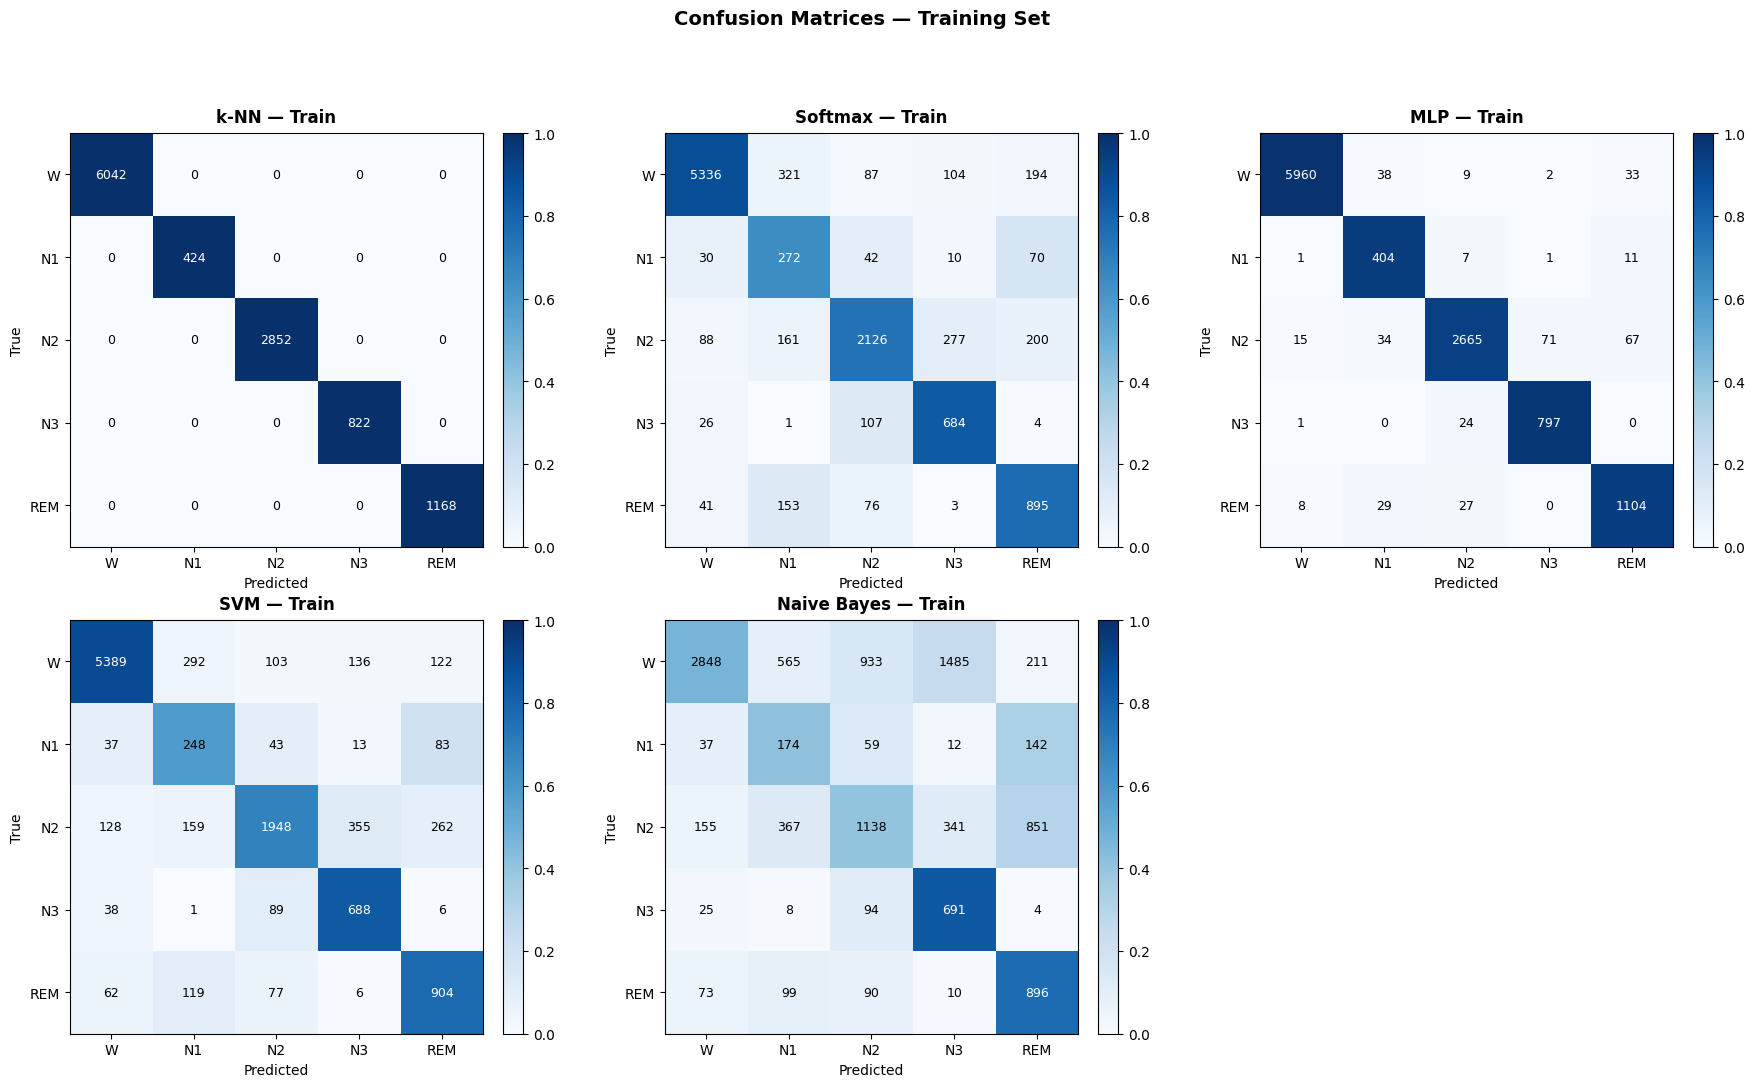

Saved → /content/fig1_train_confusion.png

Plotting Figure 2: Test confusion matrices...


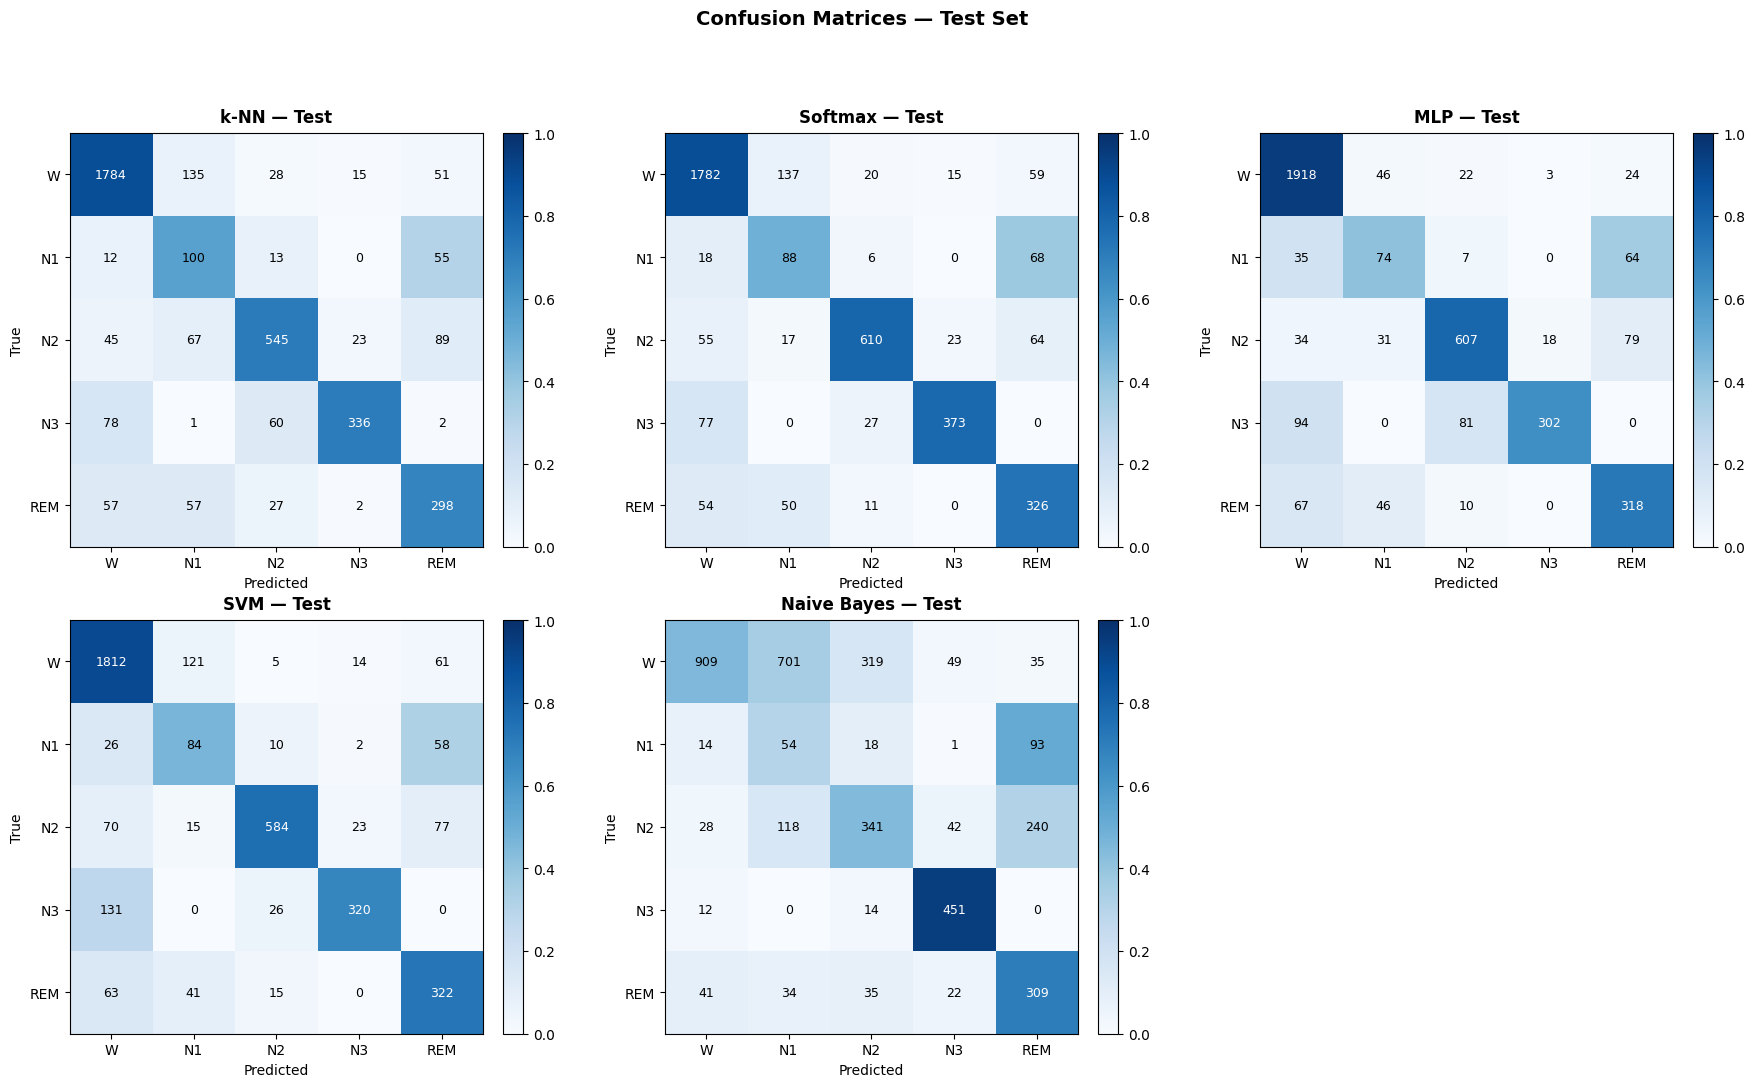

Saved → /content/fig2_test_confusion.png

Plotting Figure 3: Train vs Test accuracy & F1...


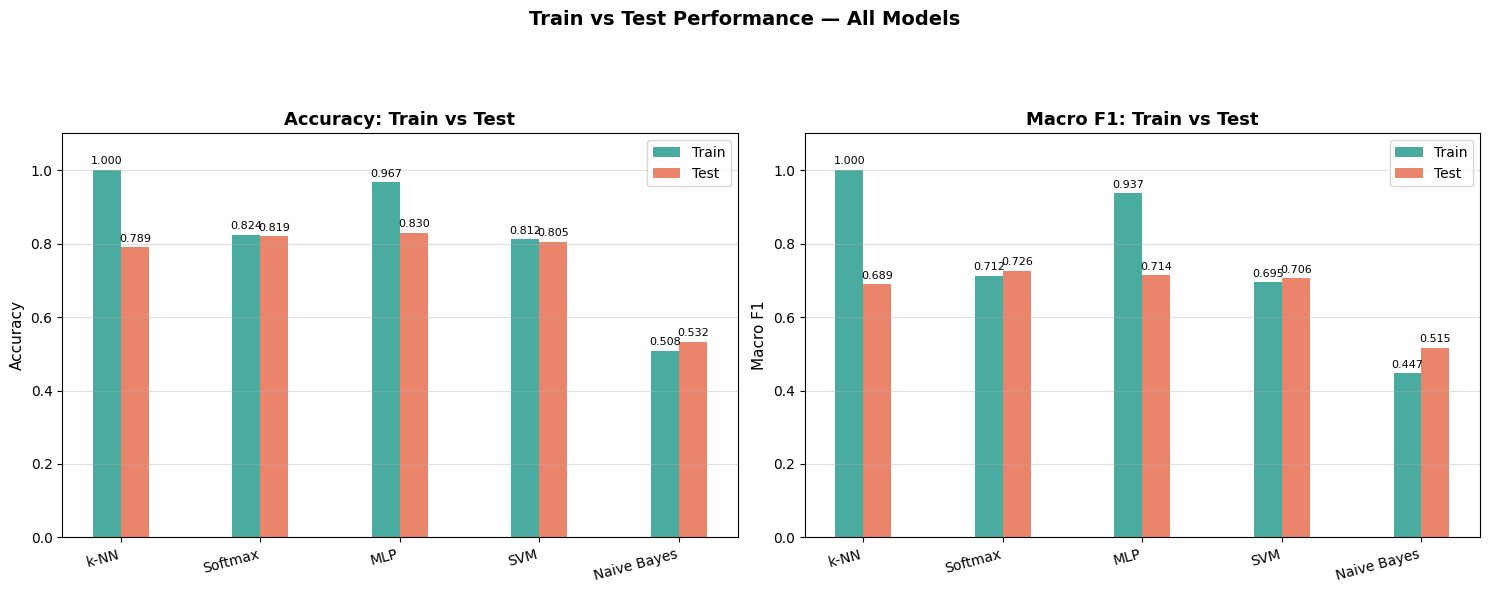

Saved → /content/fig3_train_vs_test.png

Plotting Figure 4: Per-class accuracy train vs test...


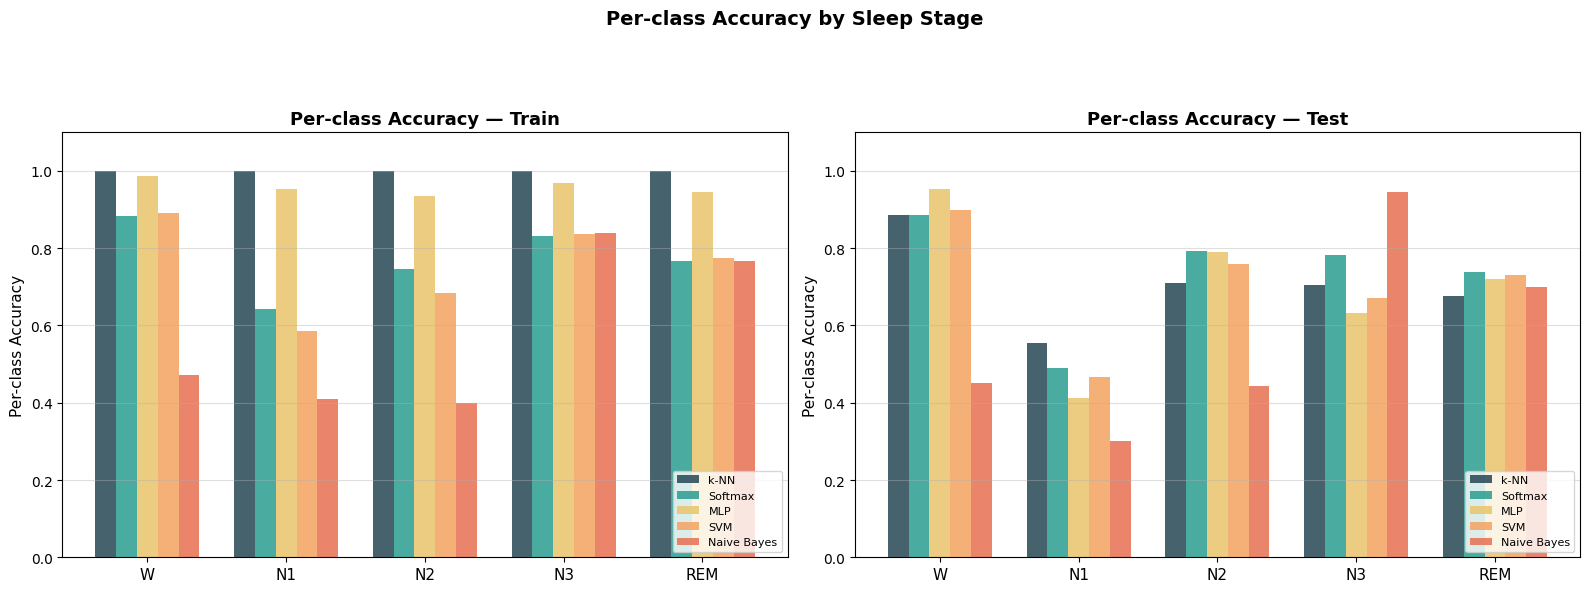

Saved → /content/fig4_per_class_accuracy.png

Plotting Figure 5: Training loss curves...


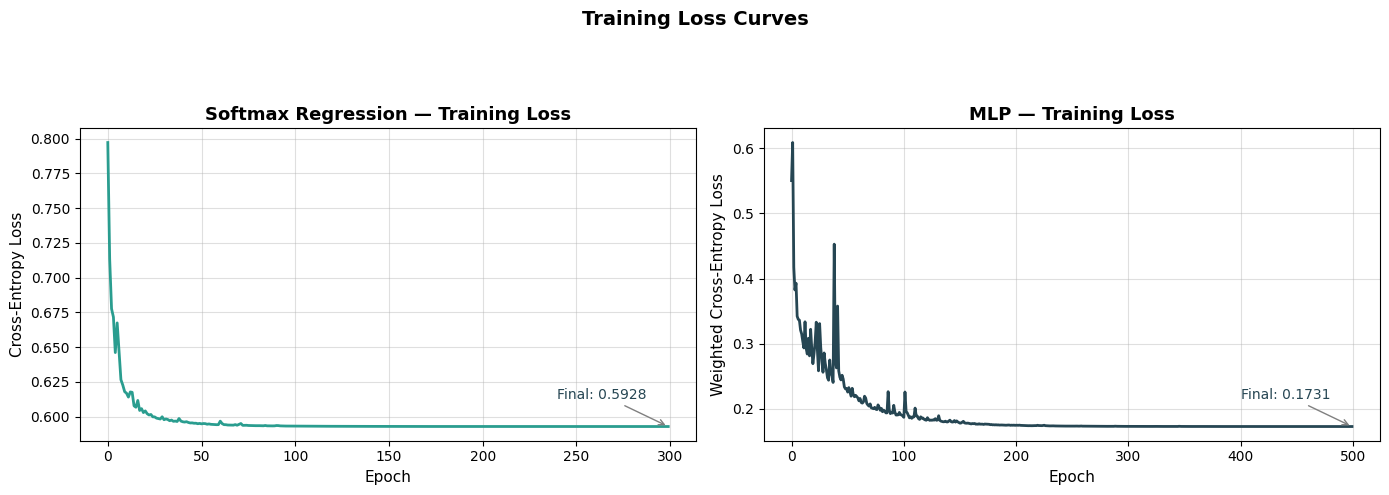

Saved → /content/fig5_training_loss.png

Plotting Figure 6: Train error vs Test error...


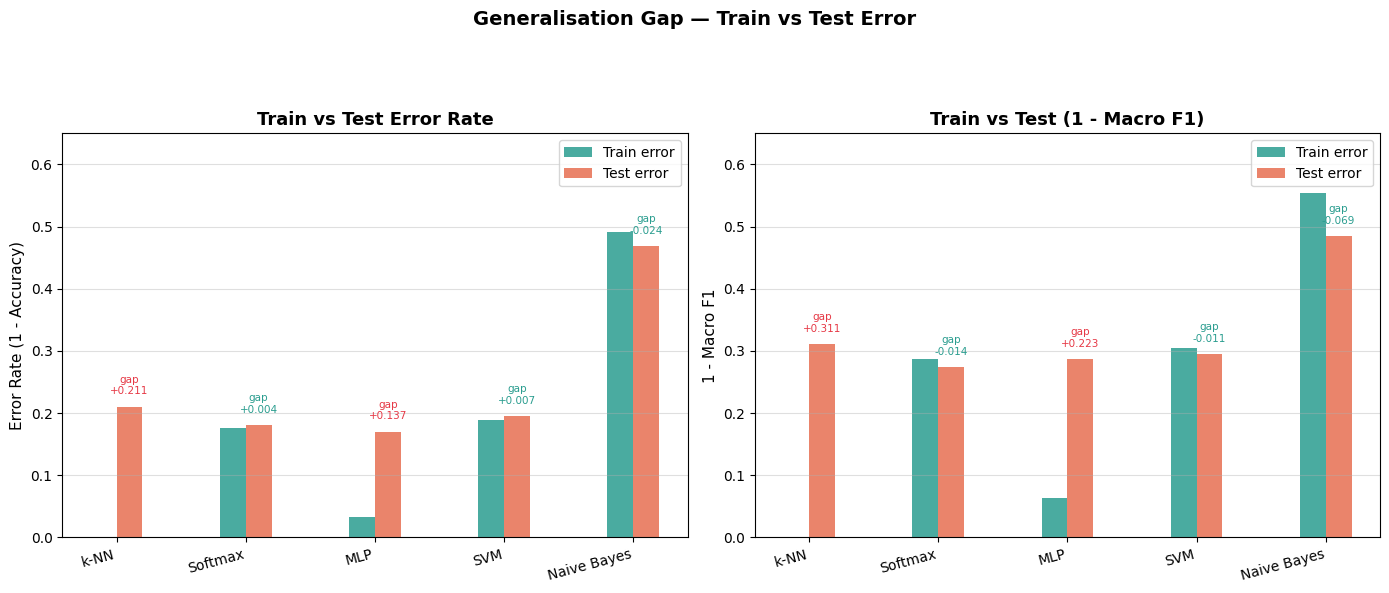

Saved → /content/fig6_generalisation_gap.png

FULL RESULTS SUMMARY — TRAIN & TEST
Model            Tr-Acc   Te-Acc   Gap-Acc    Tr-F1    Te-F1    Gap-F1
------------------------------------------------------------------------
k-NN             1.0000   0.7894   -0.2106   1.0000   0.6891   -0.3109
Softmax          0.8236   0.8193   -0.0042   0.7125   0.7260   +0.0136
MLP              0.9666   0.8296   -0.1369   0.9367   0.7136   -0.2231
SVM              0.8115   0.8046   -0.0069   0.6949   0.7055   +0.0107
Naive Bayes      0.5082   0.5320   +0.0237   0.4465   0.5152   +0.0687

Negative gap = model generalises well (test ≥ train)
Large positive gap = overfitting


In [ ]:
"""
PLOTTING MODULE

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

INT2LABEL    = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}
VALID_STAGES = ["W", "N1", "N2", "N3", "REM"]
N_CLASSES    = 5
COLORS       = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

# ─────────────────────────────────────────────────────────────────────────────
#  HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _confusion_matrix(y_true, y_pred, n=N_CLASSES):
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def _macro_f1(y_true, y_pred, n=N_CLASSES):
    f1s = []
    for c in range(n):
        tp = np.sum((y_true==c)&(y_pred==c))
        fp = np.sum((y_true!=c)&(y_pred==c))
        fn = np.sum((y_true==c)&(y_pred!=c))
        p  = tp/(tp+fp+1e-12); r = tp/(tp+fn+1e-12)
        f1s.append(2*p*r/(p+r+1e-12))
    return np.mean(f1s)

def _per_class_acc(cm):
    return {INT2LABEL[i]: (cm[i,i]/cm[i].sum() if cm[i].sum()>0 else 0.)
            for i in range(cm.shape[0])}

def _draw_cm(cm, title, ax):
    # Normalize each row by its sum so colors show rates not counts
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = cm / (row_sums + 1e-9)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    labels = [INT2LABEL[i] for i in range(N_CLASSES)]
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=12, pad=8)

    # Show raw counts in cells, but color by normalized rate
    thresh = 0.6
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm_norm[i, j] > thresh else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ─────────────────────────────────────────────────────────────────────────────
#  STEP 0 — Collect train & test predictions for all models
# ─────────────────────────────────────────────────────────────────────────────

print("Computing train and test predictions for all models...")

# Standardise with the same scaler used in main()
# (X_train and X_test are already standardised in memory)

model_objects = {
    "k-NN":        knn,
    "Softmax":     softmax,
    "MLP":         mlp,
    "SVM":         svm,
    "Naive Bayes": gnb,
}

train_results = {}
for name, model in model_objects.items():
    y_tr_pred = model.predict(X_train)
    y_te_pred = model.predict(X_test)

    tr_acc = float(np.mean(y_tr_pred == y_train))
    te_acc = float(np.mean(y_te_pred == y_test))
    tr_f1  = _macro_f1(y_train, y_tr_pred)
    te_f1  = _macro_f1(y_test,  y_te_pred)
    tr_cm  = _confusion_matrix(y_train, y_tr_pred)
    te_cm  = _confusion_matrix(y_test,  y_te_pred)
    tr_pca = _per_class_acc(tr_cm)
    te_pca = _per_class_acc(te_cm)

    train_results[name] = {
        "train_acc": tr_acc, "test_acc":  te_acc,
        "train_f1":  tr_f1,  "test_f1":   te_f1,
        "train_cm":  tr_cm,  "test_cm":   te_cm,
        "train_pca": tr_pca, "test_pca":  te_pca,
    }
    print(f"  {name:<14}  train_acc={tr_acc:.4f}  test_acc={te_acc:.4f}  "
          f"train_f1={tr_f1:.4f}  test_f1={te_f1:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 1 — Training-set confusion matrices
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 1: Training confusion matrices...")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for i, (name, r) in enumerate(train_results.items()):
    _draw_cm(r["train_cm"], f"{name} — Train", axes[i])
axes[-1].set_visible(False)          # hide the 6th empty cell
fig.suptitle("Confusion Matrices — Training Set\n",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/content/fig1_train_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig1_train_confusion.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 2 — Test-set confusion matrices
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 2: Test confusion matrices...")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
for i, (name, r) in enumerate(train_results.items()):
    _draw_cm(r["test_cm"], f"{name} — Test", axes[i])
axes[-1].set_visible(False)
fig.suptitle("Confusion Matrices — Test Set\n",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/content/fig2_test_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig2_test_confusion.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 3 — Train vs Test accuracy & F1 (grouped bar)
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 3: Train vs Test accuracy & F1...")
model_names = list(train_results.keys())
x = np.arange(len(model_names))
w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, metric, tr_key, te_key, title in [
    (axes[0], "Accuracy", "train_acc", "test_acc",  "Accuracy: Train vs Test"),
    (axes[1], "Macro F1", "train_f1",  "test_f1",   "Macro F1: Train vs Test"),
]:
    tr_vals = [train_results[m][tr_key] for m in model_names]
    te_vals = [train_results[m][te_key] for m in model_names]
    bars_tr = ax.bar(x - w/2, tr_vals, w, label="Train", color="#2a9d8f", alpha=0.85)
    bars_te = ax.bar(x + w/2, te_vals, w, label="Test",  color="#e76f51", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.4)
    # Value labels
    for bar in bars_tr:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)
    for bar in bars_te:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)

fig.suptitle("Train vs Test Performance — All Models\n",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/content/fig3_train_vs_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig3_train_vs_test.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 4 — Per-class accuracy: Train vs Test side by side
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 4: Per-class accuracy train vs test...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
stages = VALID_STAGES
xs = np.arange(len(stages))
bar_w = 0.15

for ax, pca_key, split_label in [
    (axes[0], "train_pca", "Train"),
    (axes[1], "test_pca",  "Test"),
]:
    for mi, (name, r) in enumerate(train_results.items()):
        vals = [r[pca_key][s] for s in stages]
        ax.bar(xs + mi*bar_w, vals, bar_w, label=name,
               color=COLORS[mi % len(COLORS)], alpha=0.85)
    ax.set_xticks(xs + bar_w*2)
    ax.set_xticklabels(stages, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Per-class Accuracy", fontsize=11)
    ax.set_title(f"Per-class Accuracy — {split_label}", fontweight="bold", fontsize=13)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="y", alpha=0.4)

fig.suptitle("Per-class Accuracy by Sleep Stage\n",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/content/fig4_per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig4_per_class_accuracy.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 5 — Training loss curves (Softmax & MLP)
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 5: Training loss curves...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Softmax loss
ax = axes[0]
ax.plot(softmax.loss_history, color="#2a9d8f", lw=2)
ax.set_title("Softmax Regression — Training Loss", fontweight="bold", fontsize=13)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Cross-Entropy Loss", fontsize=11)
ax.grid(alpha=0.4)
ax.annotate(f"Final: {softmax.loss_history[-1]:.4f}",
            xy=(len(softmax.loss_history)-1, softmax.loss_history[-1]),
            xytext=(-80, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=10, color="#264653")

# MLP loss
ax = axes[1]
ax.plot(mlp.loss_history, color="#264653", lw=2)
ax.set_title("MLP — Training Loss", fontweight="bold", fontsize=13)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Weighted Cross-Entropy Loss", fontsize=11)
ax.grid(alpha=0.4)
ax.annotate(f"Final: {mlp.loss_history[-1]:.4f}",
            xy=(len(mlp.loss_history)-1, mlp.loss_history[-1]),
            xytext=(-80, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="gray"),
            fontsize=10, color="#264653")

fig.suptitle("Training Loss Curves\n",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/content/fig5_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig5_training_loss.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 6 — Train error vs Test error (overfitting check)
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 6: Train error vs Test error...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, tr_key, te_key, title in [
    (axes[0], "Error Rate (1 - Accuracy)", "train_acc", "test_acc",
     "Train vs Test Error Rate"),
    (axes[1], "1 - Macro F1", "train_f1", "test_f1",
     "Train vs Test (1 - Macro F1)"),
]:
    tr_err = [1 - train_results[m][tr_key] for m in model_names]
    te_err = [1 - train_results[m][te_key] for m in model_names]
    gap    = [te - tr for te, tr in zip(te_err, tr_err)]

    ax.bar(x - w/2, tr_err, w, label="Train error", color="#2a9d8f", alpha=0.85)
    ax.bar(x + w/2, te_err, w, label="Test error",  color="#e76f51", alpha=0.85)

    # Annotate generalisation gap
    for xi, (tr, te, g) in enumerate(zip(tr_err, te_err, gap)):
        color = "#e63946" if g > 0.05 else "#2a9d8f"
        ax.annotate(f"gap\n{g:+.3f}",
                    xy=(xi + w/2, te), xytext=(xi + w/2, te + 0.02),
                    ha="center", fontsize=7.5, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right", fontsize=10)
    ax.set_ylim(0, 0.65)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.4)

fig.suptitle("Generalisation Gap — Train vs Test Error\n",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/content/fig6_generalisation_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig6_generalisation_gap.png")

# ─────────────────────────────────────────────────────────────────────────────
#  PRINT FULL SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*72)
print("FULL RESULTS SUMMARY — TRAIN & TEST")
print("="*72)
print(f"{'Model':<14} {'Tr-Acc':>8} {'Te-Acc':>8} {'Gap-Acc':>9} "
      f"{'Tr-F1':>8} {'Te-F1':>8} {'Gap-F1':>9}")
print("-"*72)
for name, r in train_results.items():
    g_acc = r["test_acc"] - r["train_acc"]
    g_f1  = r["test_f1"]  - r["train_f1"]
    print(f"{name:<14} {r['train_acc']:>8.4f} {r['test_acc']:>8.4f} {g_acc:>+9.4f} "
          f"{r['train_f1']:>8.4f} {r['test_f1']:>8.4f} {g_f1:>+9.4f}")

print("\nNegative gap = model generalises well (test ≥ train)")
print("Large positive gap = overfitting")


Loaded 2829 valid epochs from sc4002e0
Class counts: {'W': 1885, 'N1': 59, 'N2': 373, 'N3': 297, 'REM': 215}

Plotting Figure A: Raw EEG signals per stage...


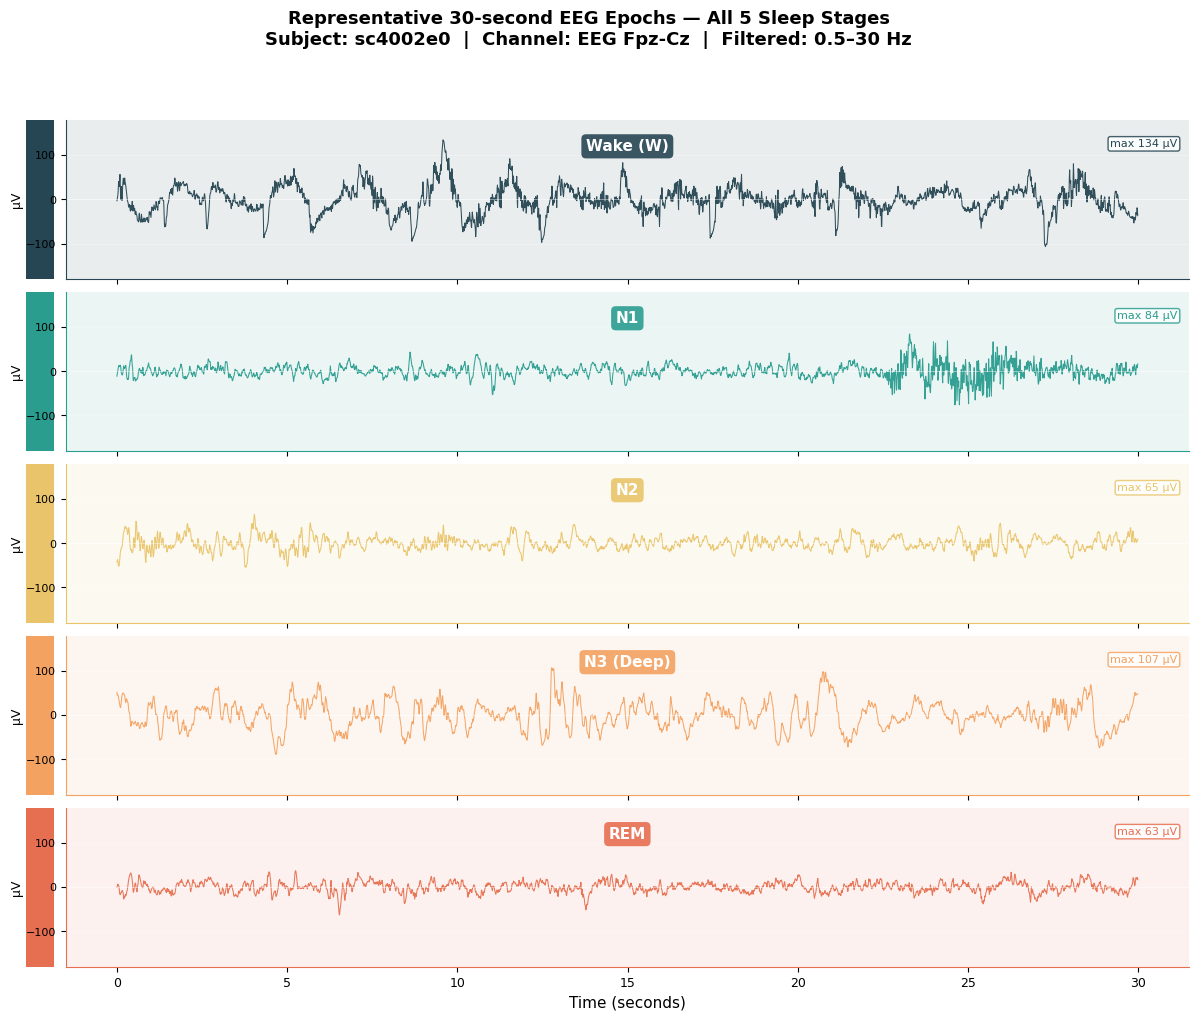

Saved → /content/figA_raw_eeg.png

Plotting Figure B: Hypnogram...


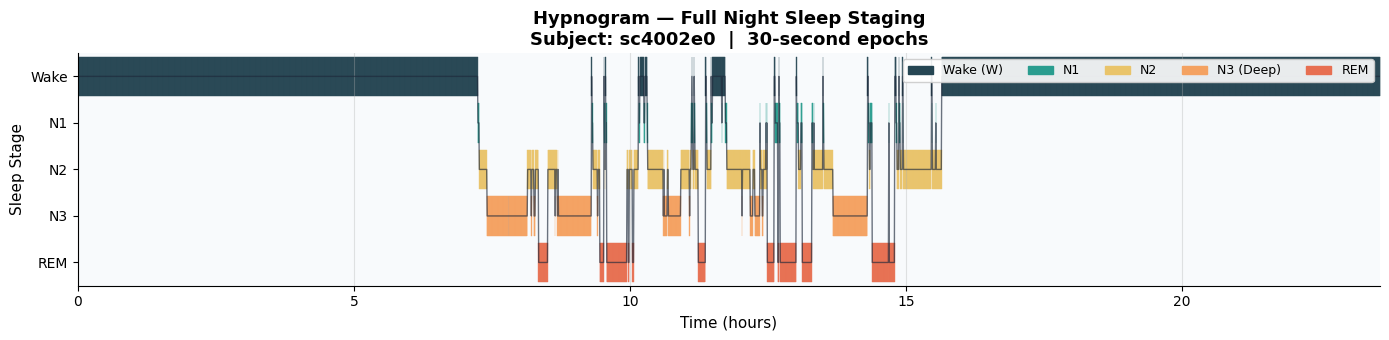

Saved → /content/figB_hypnogram.png

Plotting Figure C: PSD per stage...


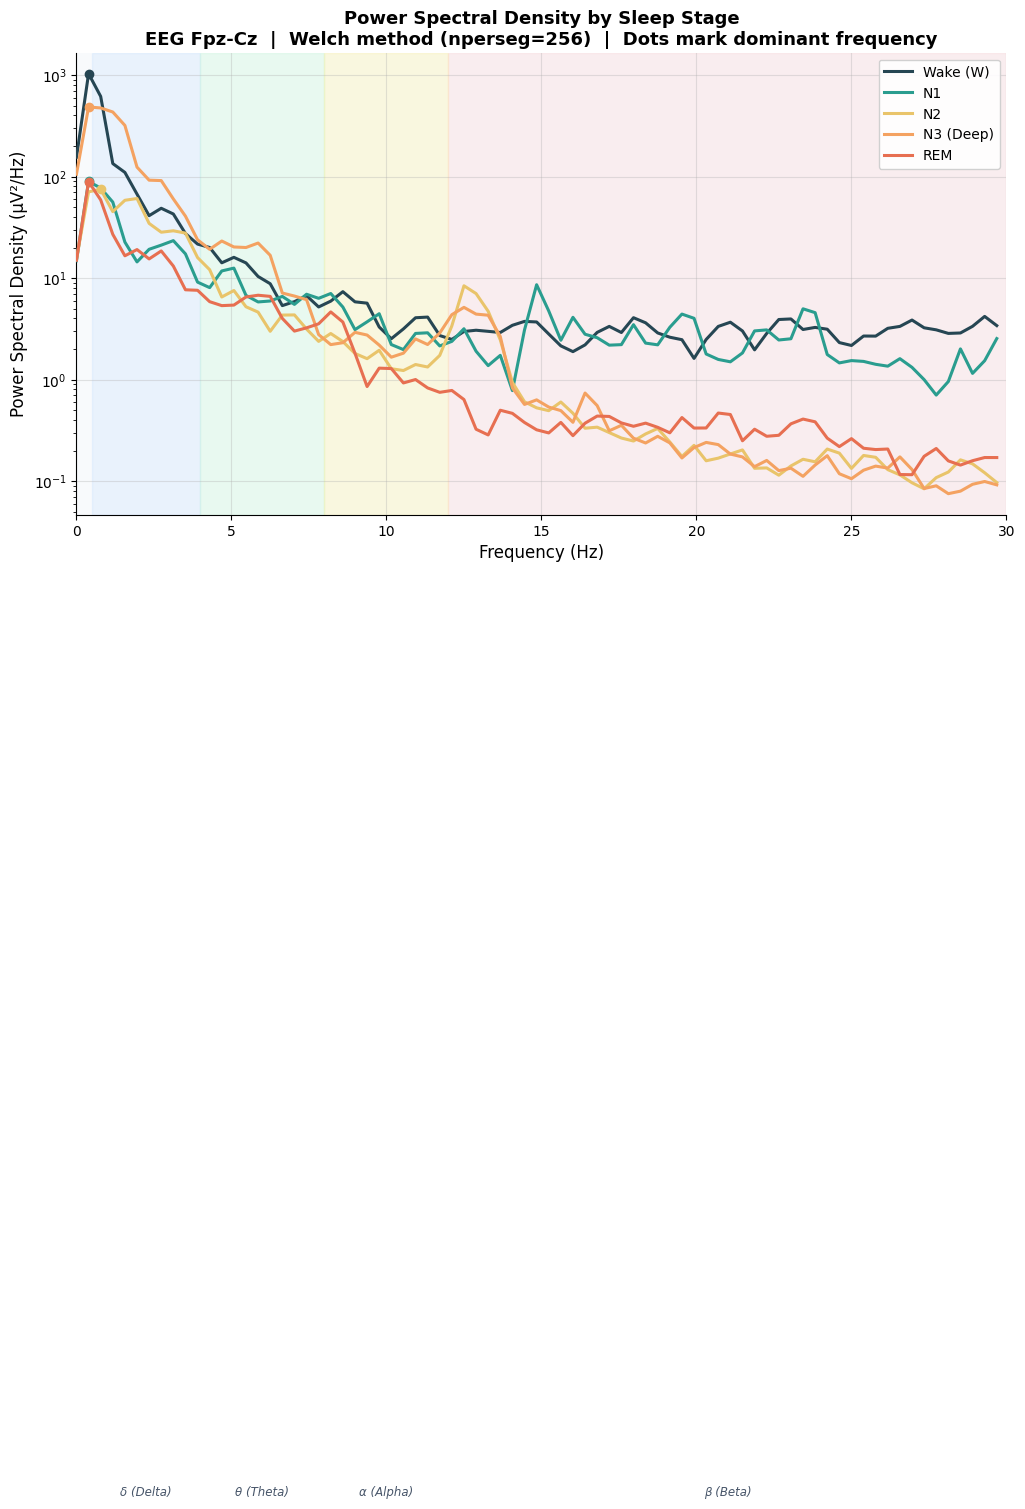

Saved → /content/figC_psd.png

Plotting Figure D: Class distribution...


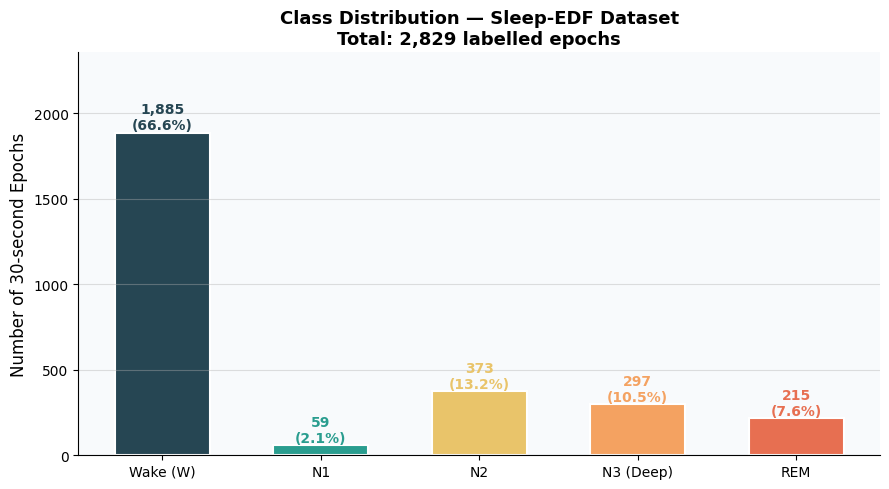

Saved → /content/figD_class_dist.png

Plotting Figure E: Pipeline diagram...


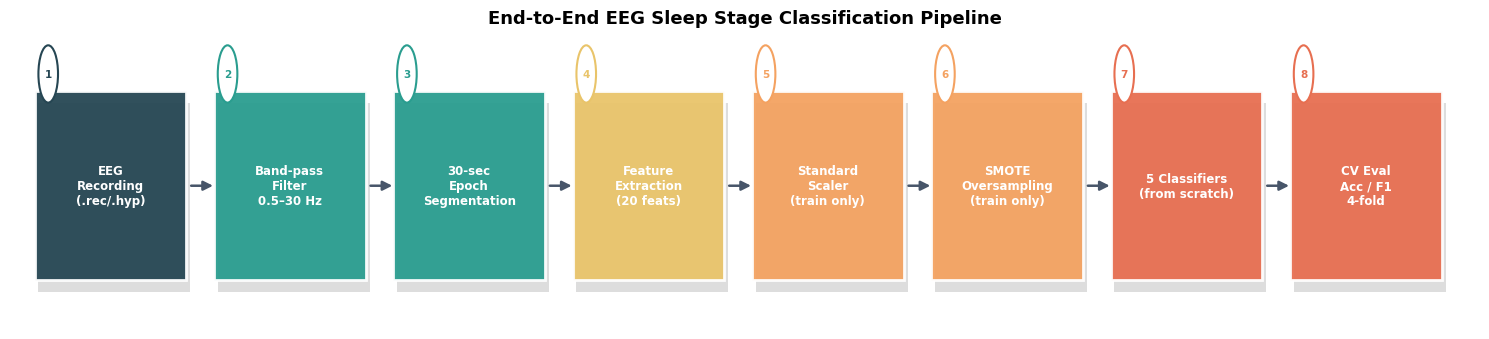

Saved → /content/figE_pipeline.png

✓ All figures saved:
  /content/figA_raw_eeg.png    — EEG epochs with stage labels
  /content/figB_hypnogram.png  — Full night hypnogram
  /content/figC_psd.png        — PSD per stage
  /content/figD_class_dist.png — Class distribution
  /content/figE_pipeline.png   — Processing pipeline

Remember to update report_final.tex:
  figB_psd.png        →  figC_psd.png
  figC_class_dist.png →  figD_class_dist.png
  figD_pipeline.png   →  figE_pipeline.png
  Add: \includegraphics{figB_hypnogram.png} in Section II


In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import welch
import mne
import shutil
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
#  STAGE DEFINITIONS
# ─────────────────────────────────────────────────────────────────────────────

INT2LABEL = {0: "W", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}
LABEL2INT = {"W": 0, "N1": 1, "N2": 2, "N3": 3, "REM": 4}

# Sleep-EDF style annotation mapping:
# 0=W, 1=N1, 2=N2, 3=N3, 4=N3 (merged N4 into N3), 5=REM, 6=MOV, 9=UNK
STAGE_MAP = {0: "W", 1: "N1", 2: "N2", 3: "N3", 4: "N3", 5: "REM", 6: "MOV", 9: "UNK"}

VALID_STAGES = ["W", "N1", "N2", "N3", "REM"]
N_CLASSES = 5

STAGE_COLORS = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
STAGE_NAMES = ["Wake (W)", "N1", "N2", "N3 (Deep)", "REM"]

# Explicit y positions for the hypnogram.
# Top-to-bottom in the plot will be Wake, N1, N2, N3, REM.
STAGE_TO_Y = {"REM": 0, "N3": 1, "N2": 2, "N1": 3, "W": 4}
Y_TO_STAGE_LABEL = ["REM", "N3", "N2", "N1", "Wake"]

# ─────────────────────────────────────────────────────────────────────────────
#  LOAD ONE SUBJECT
# ─────────────────────────────────────────────────────────────────────────────

extract_path = Path("/content/sleep_edf/sleep-edf-database-1.0.0")
rec_files = sorted(extract_path.glob("**/*.rec"))
hyp_files = sorted(extract_path.glob("**/*.hyp"))

if not rec_files or not hyp_files:
    raise FileNotFoundError("No .rec or .hyp files found under the Sleep-EDF folder.")

def copy_to_temp(src, name):
    dst = f"/content/{name}.edf"
    shutil.copy(str(src), dst)
    return dst

rec_file = rec_files[0]
hyp_file = hyp_files[0]

rec_edf = copy_to_temp(rec_file, rec_file.stem + "_rec_fig")
hyp_edf = copy_to_temp(hyp_file, hyp_file.stem + "_hyp_fig")

raw = mne.io.read_raw_edf(rec_edf, preload=True, verbose=False)

# Keep the channel used in the original code
raw.pick(["EEG Fpz-Cz"])
raw.filter(0.5, 30.0, fir_design="firwin", verbose=False)
fs = int(raw.info["sfreq"])

hyp_raw = mne.io.read_raw_edf(hyp_edf, preload=True, verbose=False)
hyp_data = hyp_raw.get_data()[0]

labels_all = [STAGE_MAP.get(int(v), "UNK") for v in hyp_data]

epochs = mne.make_fixed_length_epochs(
    raw, duration=30.0, overlap=0.0, preload=True, verbose=False
)

n = min(len(epochs), len(labels_all))

# Full label sequence for hypnogram, invalid/unknown stages become -1
hyp_seq = [LABEL2INT.get(labels_all[i], -1) for i in range(n)]

# Keep only valid stages for the representative-epoch figures
valid = [i for i in range(n) if labels_all[i] in VALID_STAGES]
X_raw_epochs = epochs.get_data()[valid, 0, :]
y_str = [labels_all[i] for i in valid]
y_int = np.array([LABEL2INT[l] for l in y_str], dtype=int)
t_epoch = np.arange(X_raw_epochs.shape[1]) / fs

print(f"Loaded {len(y_int)} valid epochs from {rec_file.stem}")
print("Class counts:", {INT2LABEL[c]: int(np.sum(y_int == c)) for c in range(N_CLASSES)})

# Pick one representative epoch per stage
representative = {}
for c in range(N_CLASSES):
    idx = np.where(y_int == c)[0]
    if len(idx) == 0:
        raise ValueError(f"No epochs found for class {INT2LABEL[c]}.")
    representative[c] = X_raw_epochs[idx[len(idx) // 2]]

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE A — Raw EEG per stage with stage label panels
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure A: Raw EEG signals per stage...")

fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(N_CLASSES, 2, width_ratios=[0.025, 1], hspace=0.08, wspace=0.02)

for c in range(N_CLASSES):
    sig = representative[c]
    color = STAGE_COLORS[c]

    # Colour sidebar
    ax_bar = fig.add_subplot(gs[c, 0])
    ax_bar.set_facecolor(color)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])
    for spine in ax_bar.spines.values():
        spine.set_visible(False)

    # EEG signal
    ax = fig.add_subplot(gs[c, 1])
    ax.plot(t_epoch, sig * 1e6, color=color, lw=0.75, alpha=0.95)

    # Shaded background matching stage colour
    ax.set_facecolor(color + "18")

    # Stage label badge
    ax.text(
        0.5, 0.88, STAGE_NAMES[c],
        transform=ax.transAxes,
        ha="center", va="top", fontsize=11, fontweight="bold",
        color="white",
        bbox=dict(facecolor=color, edgecolor="none", boxstyle="round,pad=0.3", alpha=0.9),
    )

    ax.set_ylim(-180, 180)
    ax.set_ylabel("µV", fontsize=9, labelpad=2)
    ax.axhline(0, color="white", lw=0.5, alpha=0.6)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", alpha=0.25, color="white")

    if c < N_CLASSES - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Time (seconds)", fontsize=11)
        ax.tick_params(axis="x", labelsize=9)

    peak = np.max(np.abs(sig * 1e6))
    ax.text(
        0.99, 0.88, f"max {peak:.0f} µV",
        transform=ax.transAxes,
        ha="right", va="top", fontsize=8, color=color,
        bbox=dict(facecolor="white", edgecolor=color, boxstyle="round,pad=0.2", alpha=0.85),
    )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color(color)
    ax.spines["bottom"].set_color(color)

fig.suptitle(
    f"Representative 30-second EEG Epochs — All 5 Sleep Stages\n"
    f"Subject: {rec_file.stem}  |  Channel: EEG Fpz-Cz  |  Filtered: 0.5–30 Hz",
    fontsize=13, fontweight="bold", y=0.98
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/content/figA_raw_eeg.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/figA_raw_eeg.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE B — Hypnogram (full night sleep staging timeline)
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure B: Hypnogram...")

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.set_facecolor("#F8FAFC")

epoch_duration_hr = 30.0 / 3600.0
y_height = 0.85

# Draw each epoch as a colored horizontal block on the correct categorical level
last_y = STAGE_TO_Y["W"]
for i, stage in enumerate(hyp_seq):
    t_start = i * epoch_duration_hr
    t_end = (i + 1) * epoch_duration_hr

    if stage < 0:
        # Carry forward the previous stage if the label is invalid/unknown
        y = last_y
        color = "#94A3B8"
    else:
        label = INT2LABEL[stage]
        y = STAGE_TO_Y[label]
        color = STAGE_COLORS[stage]
        last_y = y

    ax.broken_barh(
        [(t_start, epoch_duration_hr)],
        (y - y_height / 2, y_height),
        facecolors=color,
        edgecolors=color,
        alpha=0.90,
        linewidth=0.3,
    )

# Add a subtle connecting line through stage centers
line_x = []
line_y = []
last_y = STAGE_TO_Y["W"]
for i, stage in enumerate(hyp_seq):
    t_mid = (i + 0.5) * epoch_duration_hr
    if stage < 0:
        y = last_y
    else:
        y = STAGE_TO_Y[INT2LABEL[stage]]
        last_y = y
    line_x.append(t_mid)
    line_y.append(y)

ax.plot(line_x, line_y, color="#1E293B", lw=1.0, alpha=0.65)

ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(Y_TO_STAGE_LABEL, fontsize=10)
ax.set_ylim(-0.5, 4.5)

ax.set_xlabel("Time (hours)", fontsize=11)
ax.set_ylabel("Sleep Stage", fontsize=11)
ax.set_title(
    f"Hypnogram — Full Night Sleep Staging\n"
    f"Subject: {rec_file.stem}  |  30-second epochs",
    fontsize=13, fontweight="bold"
)

ax.grid(axis="x", alpha=0.35)
ax.set_xlim(0, n * epoch_duration_hr)

legend_patches = [
    mpatches.Patch(color=STAGE_COLORS[c], label=STAGE_NAMES[c])
    for c in range(N_CLASSES)
]
ax.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9, ncol=5)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.savefig("/content/figB_hypnogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/figB_hypnogram.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE C — Power Spectral Density for each stage
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure C: PSD per stage...")

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor("#F8FAFC")

band_regions = [
    (0.5, 4,  "δ (Delta)", "#BFDBFE"),
    (4.0, 8,  "θ (Theta)", "#BBF7D0"),
    (8.0, 12, "α (Alpha)", "#FEF08A"),
    (12.0, 30, "β (Beta)", "#FECACA"),
]

for fmin, fmax, bname, bcolor in band_regions:
    ax.axvspan(fmin, fmax, alpha=0.25, color=bcolor, zorder=0)
    ax.text((fmin + fmax) / 2, 1e-11, bname,
            ha="center", fontsize=8.5, color="#475569", fontstyle="italic")

for c in range(N_CLASSES):
    sig = representative[c]
    freqs, psd = welch(sig, fs=fs, nperseg=min(256, len(sig)))
    mask = freqs <= 30

    ax.semilogy(
        freqs[mask], psd[mask] * 1e12,
        color=STAGE_COLORS[c], lw=2.2,
        label=STAGE_NAMES[c], zorder=3
    )

    psd_band = psd[mask] * 1e12
    freq_band = freqs[mask]
    peak_idx = np.argmax(psd_band)
    ax.plot(freq_band[peak_idx], psd_band[peak_idx], "o",
            color=STAGE_COLORS[c], ms=6, zorder=5)

ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Power Spectral Density (µV²/Hz)", fontsize=12)
ax.set_title(
    "Power Spectral Density by Sleep Stage\n"
    "EEG Fpz-Cz  |  Welch method (nperseg=256)  |  Dots mark dominant frequency",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)
ax.grid(alpha=0.35)
ax.set_xlim(0, 30)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.savefig("/content/figC_psd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/figC_psd.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE D — Class distribution bar chart
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure D: Class distribution...")

counts = {INT2LABEL[c]: int(np.sum(y_int == c)) for c in range(N_CLASSES)}
total_epochs = sum(counts.values())

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor("#F8FAFC")

bars = ax.bar(
    [STAGE_NAMES[i] for i in range(N_CLASSES)],
    [counts[INT2LABEL[i]] for i in range(N_CLASSES)],
    color=STAGE_COLORS,
    edgecolor="white",
    linewidth=1.5,
    width=0.6
)

ax.set_ylabel("Number of 30-second Epochs", fontsize=12)
ax.set_title(
    f"Class Distribution — Sleep-EDF Dataset\n"
    f"Total: {total_epochs:,} labelled epochs",
    fontsize=13, fontweight="bold"
)
ax.grid(axis="y", alpha=0.4)

for i, bar in enumerate(bars):
    cnt = int(bar.get_height())
    pct = 100.0 * cnt / total_epochs if total_epochs else 0.0
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        cnt + max(total_epochs * 0.005, 20),
        f"{cnt:,}\n({pct:.1f}%)",
        ha="center", fontsize=10, fontweight="bold",
        color=STAGE_COLORS[i]
    )

ax.set_ylim(0, max([bar.get_height() for bar in bars]) * 1.25 if bars else 1)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.savefig("/content/figD_class_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/figD_class_dist.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE E — Pipeline diagram
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure E: Pipeline diagram...")

fig, ax = plt.subplots(figsize=(15, 3.5))
ax.set_xlim(0, 15)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_facecolor("#F8FAFC")

steps = [
    ("EEG\nRecording\n(.rec/.hyp)",      "#264653"),
    ("Band-pass\nFilter\n0.5–30 Hz",     "#2a9d8f"),
    ("30-sec\nEpoch\nSegmentation",      "#2a9d8f"),
    ("Feature\nExtraction\n(20 feats)",  "#e9c46a"),
    ("Standard\nScaler\n(train only)",   "#f4a261"),
    ("SMOTE\nOversampling\n(train only)", "#f4a261"),
    ("5 Classifiers\n(from scratch)",    "#e76f51"),
    ("CV Eval\nAcc / F1\n4-fold",        "#e76f51"),
]

box_w = 1.55
box_h = 0.66
y_c = 0.5
x0 = 0.25
gap = 1.83

for i, (label, color) in enumerate(steps):
    x = x0 + i * gap

    # shadow
    ax.add_patch(plt.Rectangle((x + 0.04, y_c - box_h / 2 - 0.04), box_w, box_h,
                               facecolor="#00000022", zorder=1))
    # box
    ax.add_patch(plt.Rectangle((x, y_c - box_h / 2), box_w, box_h,
                               facecolor=color, edgecolor="white",
                               linewidth=2, alpha=0.95, zorder=2))
    # text
    ax.text(x + box_w / 2, y_c, label,
            ha="center", va="center",
            fontsize=8.5, color="white", fontweight="bold", zorder=3)
    # step number
    ax.add_patch(plt.Circle((x + 0.14, y_c + box_h / 2 + 0.06), 0.1,
                            facecolor="white", edgecolor=color,
                            linewidth=1.5, zorder=4))
    ax.text(x + 0.14, y_c + box_h / 2 + 0.06, str(i + 1),
            ha="center", va="center", fontsize=7.5,
            color=color, fontweight="bold", zorder=5)

    # arrow to next box
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x + box_w + gap - box_w + 0.02, y_c),
            xytext=(x + box_w + 0.02, y_c),
            arrowprops=dict(arrowstyle="-|>", color="#475569",
                            lw=1.8, mutation_scale=14),
            zorder=2
        )

ax.set_title("End-to-End EEG Sleep Stage Classification Pipeline",
             fontsize=13, fontweight="bold", pad=14)

fig.tight_layout()
plt.savefig("/content/figE_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/figE_pipeline.png")

print("\n✓ All figures saved:")
print("  /content/figA_raw_eeg.png    — EEG epochs with stage labels")
print("  /content/figB_hypnogram.png  — Full night hypnogram")
print("  /content/figC_psd.png        — PSD per stage")
print("  /content/figD_class_dist.png — Class distribution")
print("  /content/figE_pipeline.png   — Processing pipeline")

print("\nRemember to update report_final.tex:")
print("  figB_psd.png        →  figC_psd.png")
print("  figC_class_dist.png →  figD_class_dist.png")
print("  figD_pipeline.png   →  figE_pipeline.png")
print("  Add: \\includegraphics{figB_hypnogram.png} in Section II")

Plotting Figure 7: Scree plot...


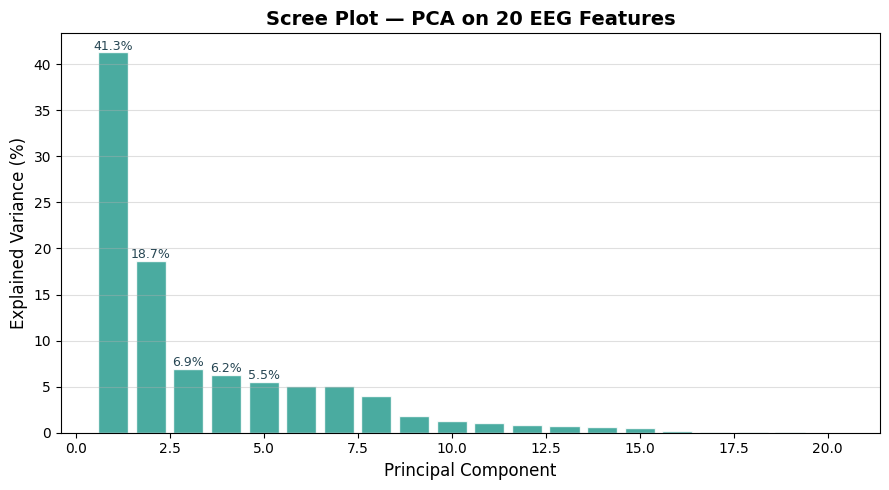

Saved → /content/fig7_scree_plot.png

Plotting Figure 8: Cumulative variance...


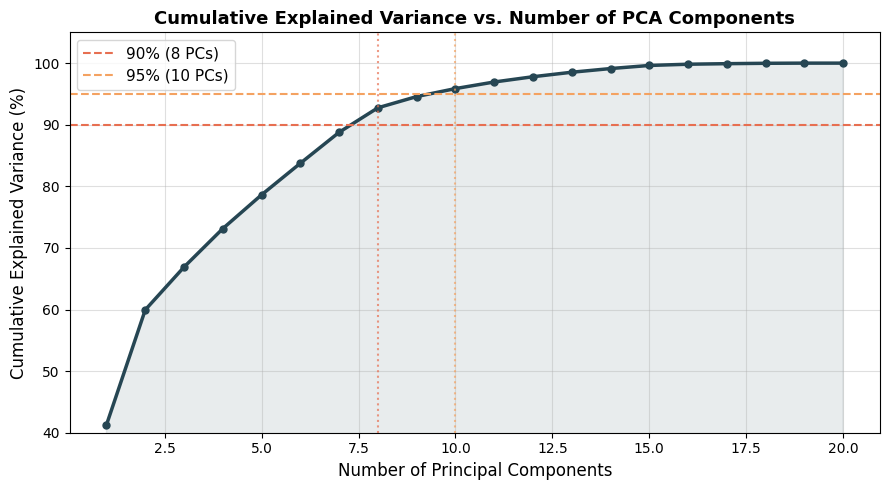

Saved → /content/fig8_cumulative_variance.png

Plotting Figure 9: 2D PCA scatter...


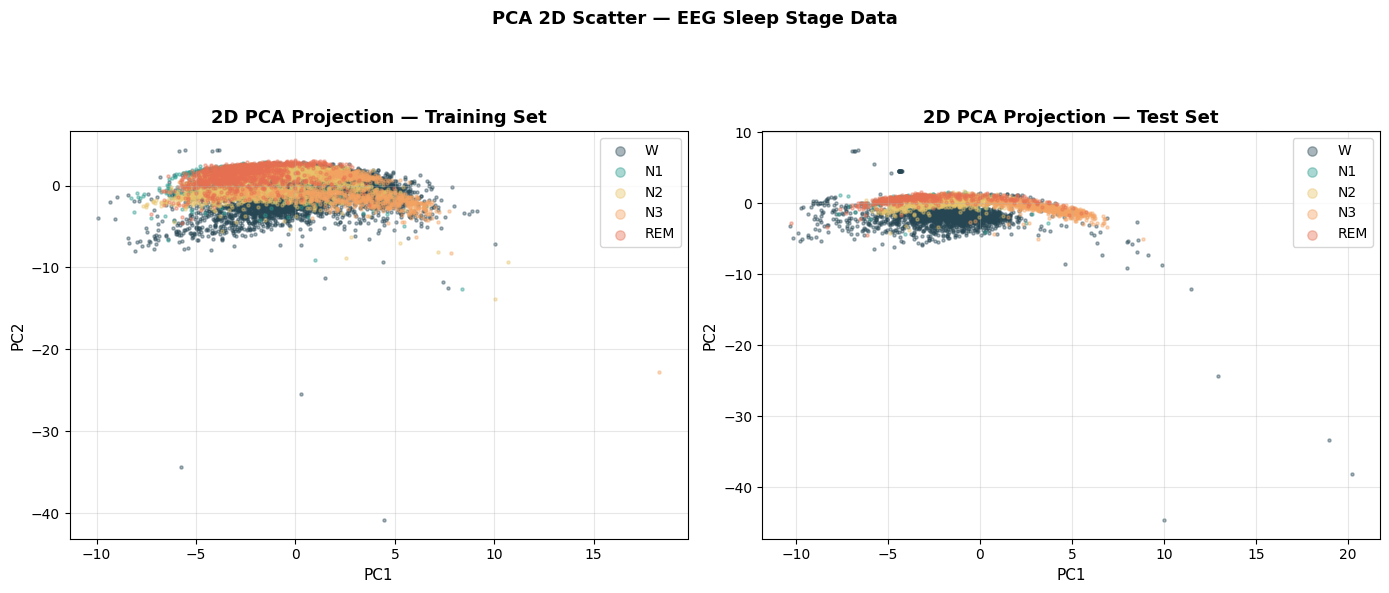

Saved → /content/fig9_pca_scatter.png

Plotting Figure 10: Accuracy vs PCA components...


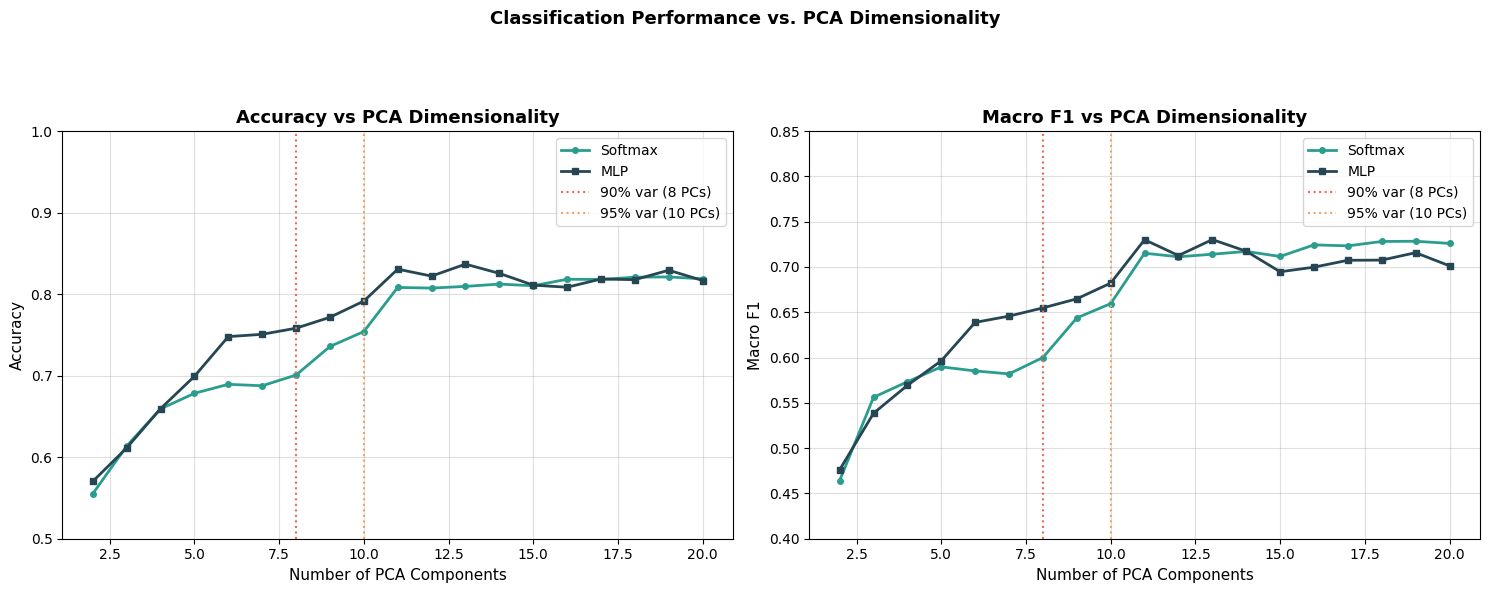

Saved → /content/fig10_pca_vs_accuracy.png

Plotting Figure 11: Cross-validation results...


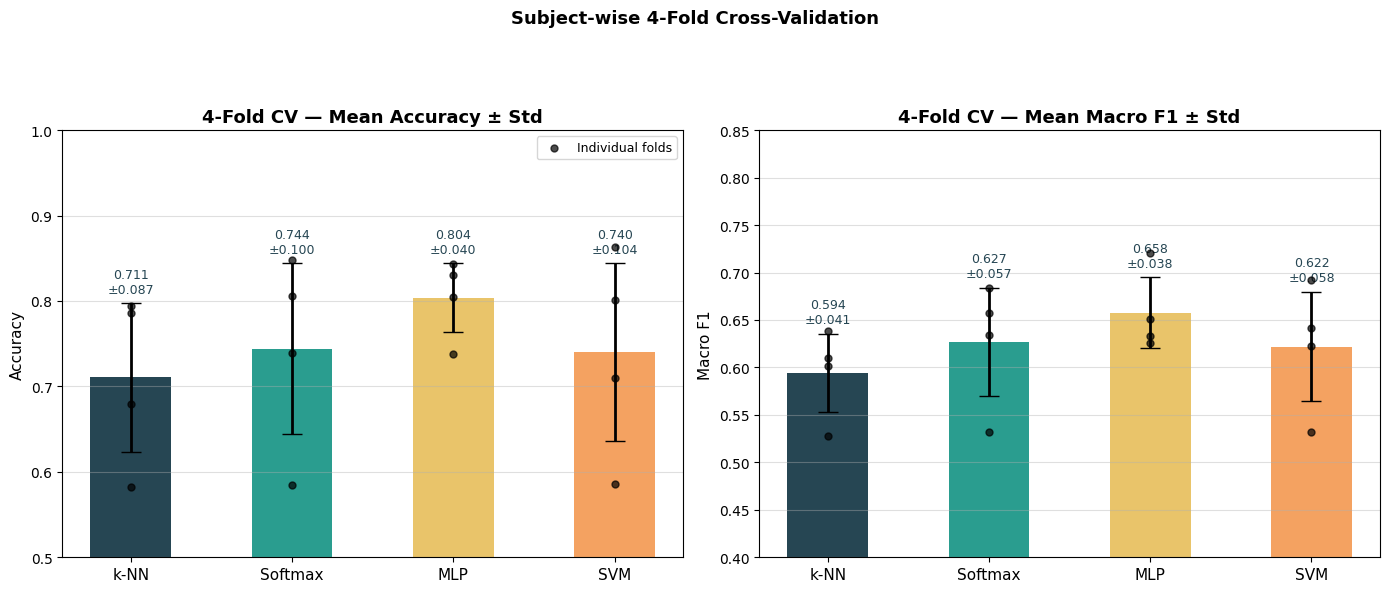

Saved → /content/fig11_cv_results.png

Plotting Figure 12: Per-fold CV breakdown...


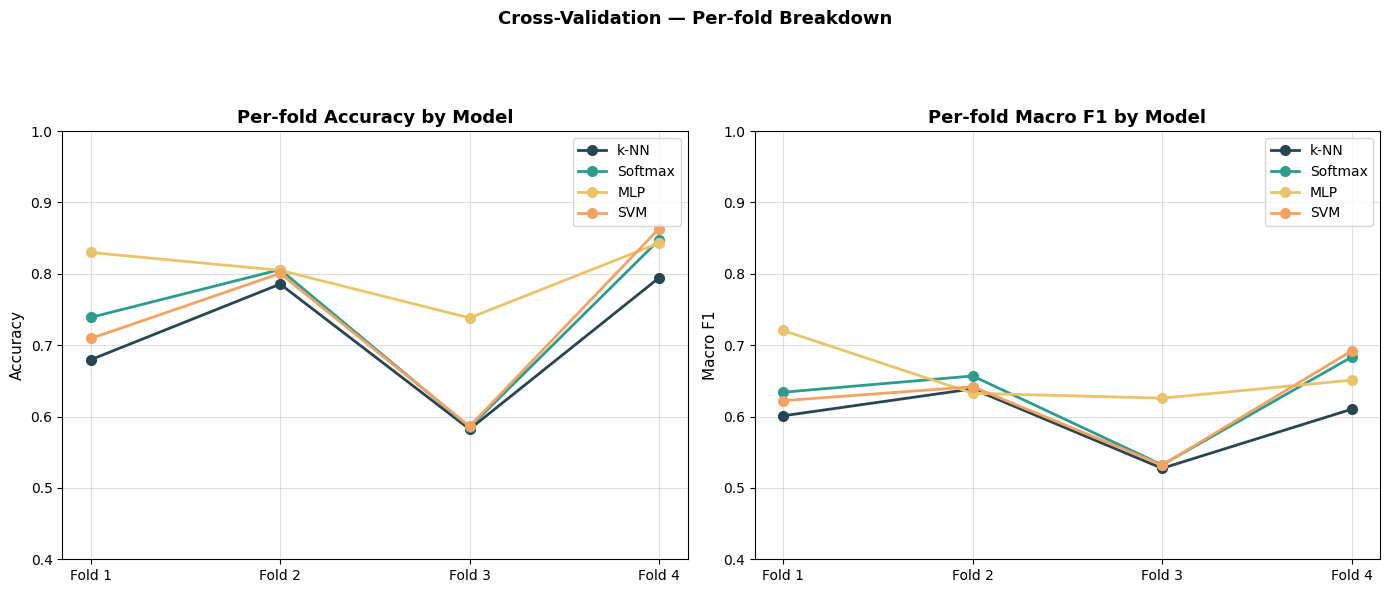

Saved → /content/fig12_cv_per_fold.png

✓ All PCA & CV figures saved to /content/


In [ ]:
"""
PCA & CV PLOTTING MODULE — Separated figures

Run this AFTER step2_pca_cv has completed.
Requires in memory: pca_res, cv_scores
"""

import numpy as np
import matplotlib.pyplot as plt

INT2LABEL    = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}
N_CLASSES    = 5
STAGE_COLORS = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 7 — Scree plot
# ─────────────────────────────────────────────────────────────────────────────

print("Plotting Figure 7: Scree plot...")
fig, ax = plt.subplots(figsize=(9, 5))
evr = pca_res["pca_full"].explained_variance_ratio_ * 100
bars = ax.bar(range(1, len(evr)+1), evr, color="#2a9d8f", alpha=0.85, edgecolor="white")
ax.set_xlabel("Principal Component", fontsize=12)
ax.set_ylabel("Explained Variance (%)", fontsize=12)
ax.set_title("Scree Plot — PCA on 20 EEG Features", fontweight="bold", fontsize=14)
ax.grid(axis="y", alpha=0.4)

# Label first few bars
for i, bar in enumerate(bars[:5]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{evr[i]:.1f}%", ha="center", fontsize=9, color="#264653")

plt.tight_layout()
plt.savefig("/content/fig7_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig7_scree_plot.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 8 — Cumulative explained variance
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 8: Cumulative variance...")
fig, ax = plt.subplots(figsize=(9, 5))
cv = pca_res["cum_var"] * 100
ax.plot(range(1, len(cv)+1), cv, color="#264653", lw=2.5, marker="o", ms=5)
ax.axhline(90, color="#e76f51", ls="--", lw=1.5, label=f"90% ({pca_res['n90']} PCs)")
ax.axhline(95, color="#f4a261", ls="--", lw=1.5, label=f"95% ({pca_res['n95']} PCs)")
ax.axvline(pca_res["n90"], color="#e76f51", ls=":", alpha=0.7)
ax.axvline(pca_res["n95"], color="#f4a261", ls=":", alpha=0.7)
ax.fill_between(range(1, len(cv)+1), cv, alpha=0.1, color="#264653")
ax.set_xlabel("Number of Principal Components", fontsize=12)
ax.set_ylabel("Cumulative Explained Variance (%)", fontsize=12)
ax.set_title("Cumulative Explained Variance vs. Number of PCA Components",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.4)
ax.set_ylim(40, 105)


plt.tight_layout()
plt.savefig("/content/fig8_cumulative_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig8_cumulative_variance.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 9 — 2D PCA scatter
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 9: 2D PCA scatter...")

# Need to recompute 2D projection
pca2 = PCA(n_components=2).fit(pca_res["Xtr"])
Xtr2 = pca2.transform(pca_res["Xtr"])
Xte2 = pca2.transform(pca_res["Xte"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, X2, y2, split in [
    (axes[0], Xtr2, pca_res["y_train"], "Training"),
    (axes[1], Xte2, pca_res["y_test"],  "Test"),
]:
    for c in range(N_CLASSES):
        mask = y2 == c
        ax.scatter(X2[mask, 0], X2[mask, 1], s=5, alpha=0.4,
                   color=STAGE_COLORS[c], label=INT2LABEL[c])
    ax.set_xlabel("PC1", fontsize=11)
    ax.set_ylabel("PC2", fontsize=11)
    ax.set_title(f"2D PCA Projection — {split} Set", fontweight="bold", fontsize=13)
    ax.legend(markerscale=3, fontsize=10)
    ax.grid(alpha=0.3)

fig.suptitle("PCA 2D Scatter — EEG Sleep Stage Data\n",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/content/fig9_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig9_pca_scatter.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 10 — Classification accuracy vs PCA components
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 10: Accuracy vs PCA components...")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

nc = pca_res["components"]

# Accuracy
ax = axes[0]
ax.plot(nc, pca_res["softmax_accs"], color="#2a9d8f", lw=2, marker="o", ms=4,
        label="Softmax")
ax.plot(nc, pca_res["mlp_accs"],     color="#264653", lw=2, marker="s", ms=4,
        label="MLP")
ax.axvline(pca_res["n90"], color="#e76f51", ls=":",
           label=f"90% var ({pca_res['n90']} PCs)")
ax.axvline(pca_res["n95"], color="#f4a261", ls=":",
           label=f"95% var ({pca_res['n95']} PCs)")
ax.set_xlabel("Number of PCA Components", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Accuracy vs PCA Dimensionality", fontweight="bold", fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.4); ax.set_ylim(0.5, 1.0)

# Macro F1
ax = axes[1]
ax.plot(nc, pca_res["softmax_f1s"], color="#2a9d8f", lw=2, marker="o", ms=4,
        label="Softmax")
ax.plot(nc, pca_res["mlp_f1s"],     color="#264653", lw=2, marker="s", ms=4,
        label="MLP")
ax.axvline(pca_res["n90"], color="#e76f51", ls=":",
           label=f"90% var ({pca_res['n90']} PCs)")
ax.axvline(pca_res["n95"], color="#f4a261", ls=":",
           label=f"95% var ({pca_res['n95']} PCs)")
ax.set_xlabel("Number of PCA Components", fontsize=11)
ax.set_ylabel("Macro F1", fontsize=11)
ax.set_title("Macro F1 vs PCA Dimensionality", fontweight="bold", fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.4); ax.set_ylim(0.4, 0.85)

fig.suptitle("Classification Performance vs. PCA Dimensionality\n",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/content/fig10_pca_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig10_pca_vs_accuracy.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 11 — Cross-validation results (accuracy + F1 side by side)
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 11: Cross-validation results...")
models  = list(cv_scores.keys())
accs    = [np.mean(cv_scores[m]["acc"]) for m in models]
acc_std = [np.std(cv_scores[m]["acc"])  for m in models]
f1s     = [np.mean(cv_scores[m]["f1"])  for m in models]
f1_std  = [np.std(cv_scores[m]["f1"])   for m in models]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(models))
bar_colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261"]

for ax, vals, stds, metric, ylim in [
    (axes[0], accs, acc_std, "Accuracy", (0.5, 1.0)),
    (axes[1], f1s,  f1_std,  "Macro F1", (0.4, 0.85)),
]:
    bars = ax.bar(x, vals, yerr=stds, capsize=7, width=0.5,
                  color=bar_colors,
                  error_kw={"elinewidth": 2, "ecolor": "black"})
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylim(*ylim)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"4-Fold CV — Mean {metric} ± Std", fontweight="bold", fontsize=13)
    ax.grid(axis="y", alpha=0.4)
    for xi, (v, s) in enumerate(zip(vals, stds)):
        ax.text(xi, v + s + 0.008, f"{v:.3f}\n±{s:.3f}",
                ha="center", va="bottom", fontsize=9, color="#264653")

    # Draw individual fold dots
    for mi, m in enumerate(models):
        fold_vals = cv_scores[m]["acc"] if metric == "Accuracy" else cv_scores[m]["f1"]
        ax.scatter([mi]*len(fold_vals), fold_vals, color="black",
                   zorder=5, s=25, alpha=0.7, label="Individual folds" if mi==0 else "")
    if metric == "Accuracy":
        ax.legend(fontsize=9)

fig.suptitle("Subject-wise 4-Fold Cross-Validation\n",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/content/fig11_cv_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig11_cv_results.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIGURE 12 — Per-fold CV breakdown (line plot)
# ─────────────────────────────────────────────────────────────────────────────

print("\nPlotting Figure 12: Per-fold CV breakdown...")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fold_labels = [f"Fold {i+1}" for i in range(4)]

for ax, key, metric in [
    (axes[0], "acc", "Accuracy"),
    (axes[1], "f1",  "Macro F1"),
]:
    for mi, m in enumerate(models):
        ax.plot(fold_labels, cv_scores[m][key], marker="o", lw=2,
                color=bar_colors[mi], label=m, ms=7)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"Per-fold {metric} by Model", fontweight="bold", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.4)
    ax.set_ylim(0.4, 1.0)

fig.suptitle("Cross-Validation — Per-fold Breakdown\n",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/content/fig12_cv_per_fold.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /content/fig12_cv_per_fold.png")

print("\n✓ All PCA & CV figures saved to /content/")


STEP 3 — FEATURE IMPORTANCE & ERROR ANALYSIS

Training Softmax for permutation importance...
Model accuracy on test set: 0.8196

Computing permutation importance (5 repeats per feature)...

Feature importance ranking:
   1. Hjorth Mobility         drop=0.2448 ± 0.0050
   2. Zero-Cross Rate         drop=0.1687 ± 0.0037
   3. Log Total Power         drop=0.1159 ± 0.0049
   4. Hjorth Complexity       drop=0.1064 ± 0.0026
   5. δ/θ                     drop=0.0862 ± 0.0038
   6. θ ratio                 drop=0.0814 ± 0.0035
   7. Dominant Freq           drop=0.0281 ± 0.0036
   8. RMS                     drop=0.0277 ± 0.0028
   9. Std Dev                 drop=0.0258 ± 0.0011
  10. β ratio                 drop=0.0197 ± 0.0011
  11. Peak-to-Peak            drop=0.0163 ± 0.0018
  12. α/β                     drop=0.0159 ± 0.0033
  13. Kurtosis                drop=0.0031 ± 0.0007
  14. δ ratio                 drop=0.0015 ± 0.0013
  15. Skewness                drop=0.0008 ± 0.0004
  16. Mean       

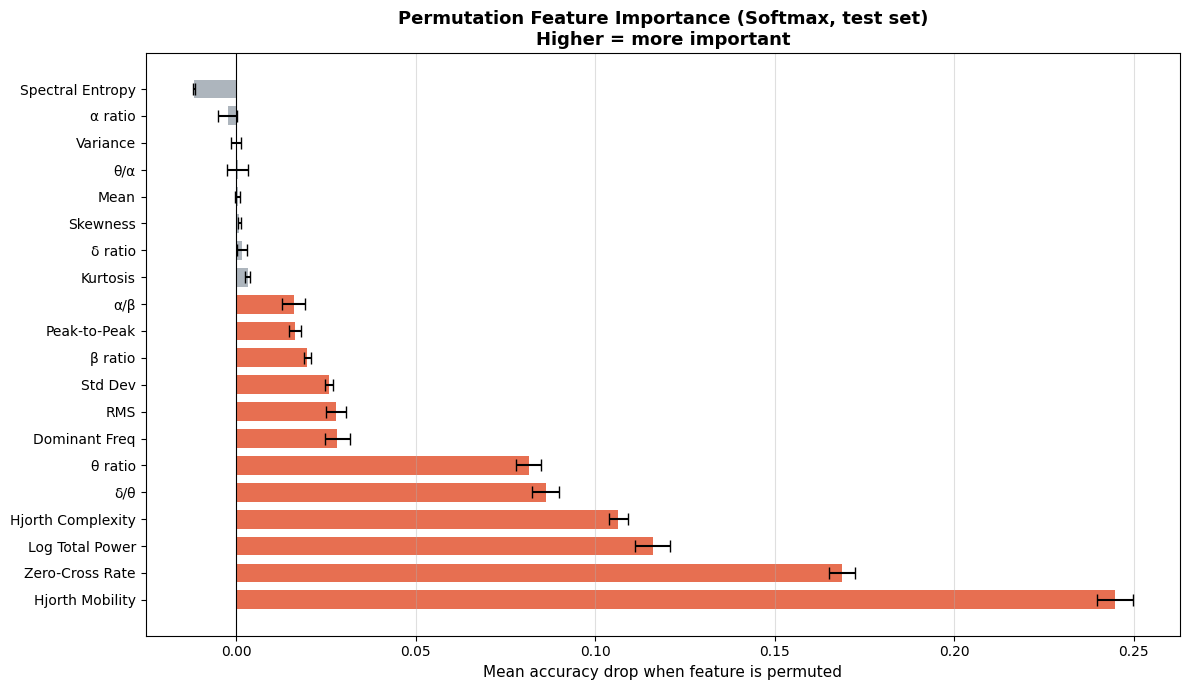

Saved → /content/feature_importance.png

Computing class-conditional feature profiles...


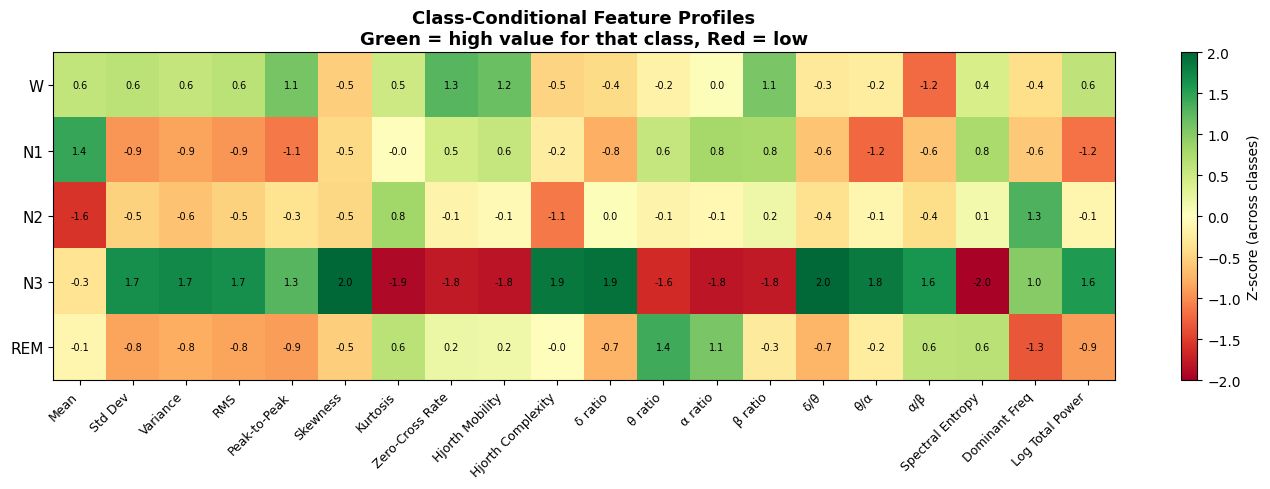

Saved → /content/feature_profiles.png


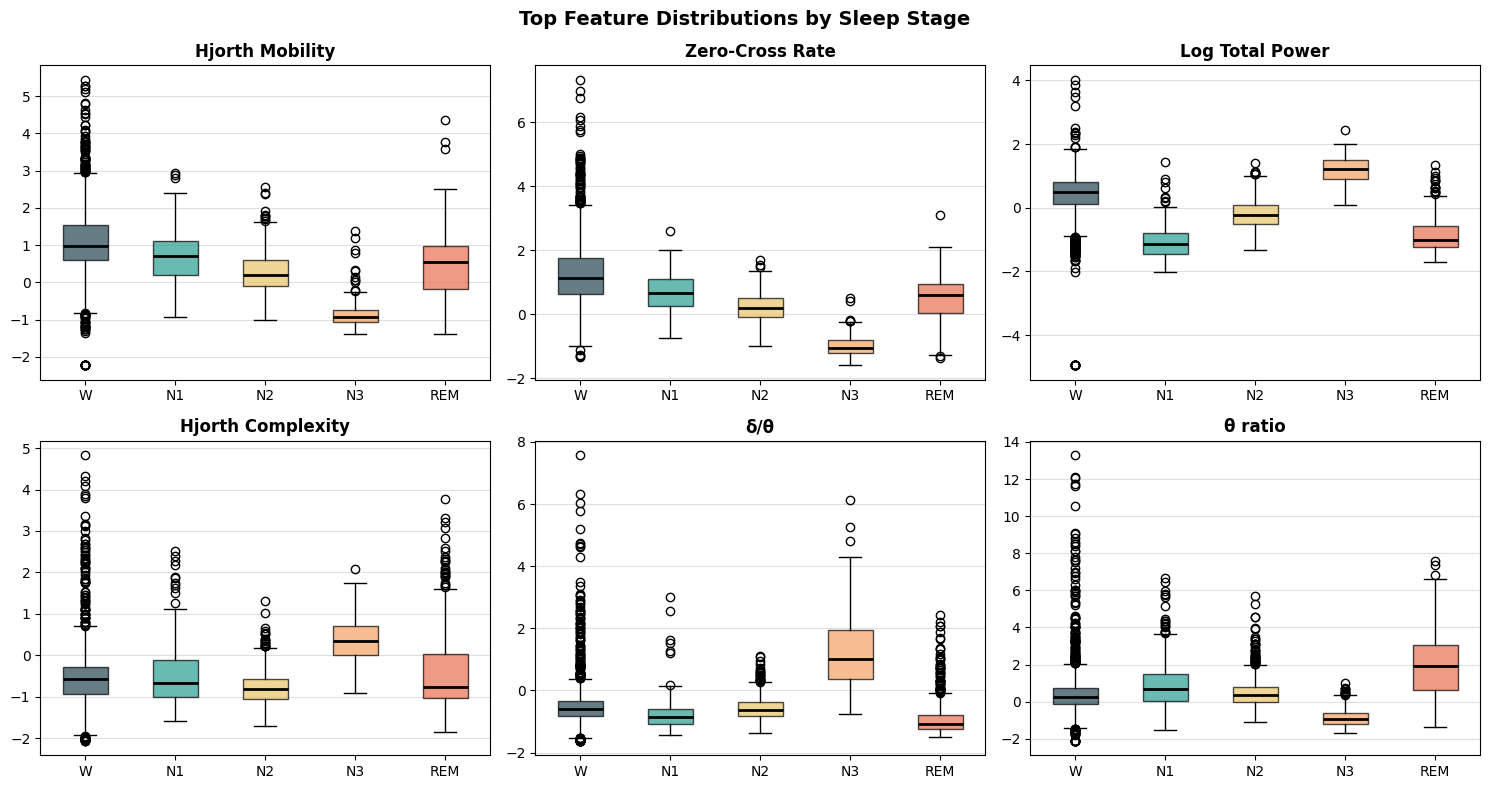

Saved → /content/feature_distributions.png

Running error analysis on MLP predictions...

ERROR ANALYSIS — MLP
Total errors: 661/3880 (17.0%)

Top misclassification pairs (True → Predicted):
    N3 → W       94 times  (2.4% of all samples)
    N3 → N2      81 times  (2.1% of all samples)
    N2 → REM     79 times  (2.0% of all samples)
   REM → W       67 times  (1.7% of all samples)
    N1 → REM     64 times  (1.6% of all samples)
     W → N1      46 times  (1.2% of all samples)
   REM → N1      46 times  (1.2% of all samples)
    N1 → W       35 times  (0.9% of all samples)
    N2 → W       34 times  (0.9% of all samples)
    N2 → N1      31 times  (0.8% of all samples)

Per-class error rate:
     W: 95/2013 errors (4.7%)
    N1: 106/180 errors (58.9%)
    N2: 162/769 errors (21.1%)
    N3: 175/477 errors (36.7%)
   REM: 123/441 errors (27.9%)

✓ Feature importance & error analysis complete.
Figures saved to /content/


In [ ]:
"""
STEP 3 — Feature Importance & Error Analysis

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

INT2LABEL  = {0:"W", 1:"N1", 2:"N2", 3:"N3", 4:"REM"}
N_CLASSES  = 5
STAGE_COLORS = ["#264653","#2a9d8f","#e9c46a","#f4a261","#e76f51"]

FEATURE_NAMES = [
    "Mean", "Std Dev", "Variance", "RMS", "Peak-to-Peak",
    "Skewness", "Kurtosis", "Zero-Cross Rate", "Hjorth Mobility", "Hjorth Complexity",
    "δ ratio", "θ ratio", "α ratio", "β ratio",
    "δ/θ", "θ/α", "α/β",
    "Spectral Entropy", "Dominant Freq", "Log Total Power"
]

# ─────────────────────────────────────────────────────────────────────────────
#  1. PERMUTATION FEATURE IMPORTANCE
#     Measures how much accuracy drops when each feature is randomly shuffled.
#     A large drop = that feature is important.
#     Advantage over weight-based importance: model-agnostic and unbiased.
# ─────────────────────────────────────────────────────────────────────────────

def permutation_importance(model, X, y, n_repeats=5, random_state=42):
    """
    For each feature j:
      1. Record baseline accuracy on (X, y)
      2. Shuffle column j   n_repeats times
      3. Importance = baseline_acc - mean(shuffled_acc)
    """
    rng = np.random.default_rng(random_state)
    baseline = np.mean(model.predict(X) == y)
    importances = np.zeros((X.shape[1], n_repeats))
    for j in range(X.shape[1]):
        for r in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])
            acc_perm = np.mean(model.predict(X_perm) == y)
            importances[j, r] = baseline - acc_perm
    return importances  # shape (n_features, n_repeats)


def _softmax(Z):
    Z = Z - Z.max(1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(1, keepdims=True)

def _one_hot(y, K=N_CLASSES):
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1.
    return Y

def smote_oversample(X, y, random_state=42):
    rng    = np.random.default_rng(random_state)
    counts = np.bincount(y, minlength=N_CLASSES)
    target = counts.max()
    Xs, ys = [X], [y]
    for c in range(N_CLASSES):
        idx  = np.where(y == c)[0]
        need = target - len(idx)
        if need <= 0: continue
        for _ in range(need):
            a, b = rng.choice(idx, 2, replace=True)
            lam  = rng.random()
            Xs.append((X[a] + lam * (X[b] - X[a]))[None])
            ys.append([c])
    return np.vstack(Xs), np.concatenate(ys)

class StandardScaler:
    def fit(self, X):
        self.mu = X.mean(0); self.sig = X.std(0)
        self.sig[self.sig == 0] = 1.; return self
    def transform(self, X): return (X - self.mu) / self.sig
    def fit_transform(self, X): return self.fit(X).transform(X)

# Lightweight Softmax for importance (fast)
class _SoftmaxFast:
    def __init__(self): pass
    def fit(self, X, y):
        n, d = X.shape
        self.W = 0.01 * np.random.randn(d, N_CLASSES)
        self.b = np.zeros((1, N_CLASSES))
        lr = 0.1
        for ep in range(200):
            idx = np.random.permutation(n)
            for s in range(0, n, 256):
                bi = idx[s:s+256]; Xb = X[bi]; Yb = _one_hot(y[bi])
                P  = _softmax(Xb @ self.W + self.b)
                self.W -= lr * (Xb.T @ (P - Yb) / len(bi) + 2e-3 * self.W)
                self.b -= lr * (P - Yb).mean(0, keepdims=True)
            lr *= 0.97
        return self
    def predict(self, X):
        return np.argmax(_softmax(X @ self.W + self.b), 1)


# ─────────────────────────────────────────────────────────────────────────────
#  2. CLASS-CONDITIONAL FEATURE DISTRIBUTIONS
#     Shows mean ± std of each feature per sleep stage.
#     Reveals which features naturally separate the classes.
# ─────────────────────────────────────────────────────────────────────────────

def compute_class_means(X, y):
    means = np.zeros((N_CLASSES, X.shape[1]))
    stds  = np.zeros((N_CLASSES, X.shape[1]))
    for c in range(N_CLASSES):
        Xc = X[y == c]
        means[c] = Xc.mean(0)
        stds[c]  = Xc.std(0)
    return means, stds


# ─────────────────────────────────────────────────────────────────────────────
#  3. ERROR ANALYSIS — what does the best model get wrong?
# ─────────────────────────────────────────────────────────────────────────────

def error_analysis(y_test, y_pred, model_name="MLP"):
    """
    Breakdown of misclassifications:
    - Which true class gets confused most?
    - Which predicted class does it get confused with?
    """
    print(f"\n{'='*55}")
    print(f"ERROR ANALYSIS — {model_name}")
    print(f"{'='*55}")
    errors = [(t, p) for t, p in zip(y_test, y_pred) if t != p]
    total_errors = len(errors)
    total = len(y_test)
    print(f"Total errors: {total_errors}/{total} ({100*total_errors/total:.1f}%)\n")

    # Confusion pairs
    from collections import Counter
    pair_counts = Counter(errors)
    print("Top misclassification pairs (True → Predicted):")
    for (t, p), cnt in pair_counts.most_common(10):
        pct = 100 * cnt / total
        print(f"  {INT2LABEL[t]:>4} → {INT2LABEL[p]:<4}  {cnt:4d} times  ({pct:.1f}% of all samples)")

    # Per-class error rate
    print("\nPer-class error rate:")
    for c in range(N_CLASSES):
        total_c  = np.sum(y_test == c)
        errors_c = np.sum((y_test == c) & (y_pred != c))
        print(f"  {INT2LABEL[c]:>4}: {errors_c}/{total_c} errors ({100*errors_c/(total_c+1e-9):.1f}%)")


# ─────────────────────────────────────────────────────────────────────────────
#  FIGURES
# ─────────────────────────────────────────────────────────────────────────────

def plot_feature_importance(imp_mean, imp_std):
    fig, ax = plt.subplots(figsize=(12, 7))
    order = np.argsort(imp_mean)[::-1]
    colors = ["#e76f51" if imp_mean[i] > 0.01 else "#adb5bd" for i in order]
    ax.barh(range(len(order)), imp_mean[order], xerr=imp_std[order],
            color=colors, capsize=4, height=0.7)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([FEATURE_NAMES[i] for i in order], fontsize=10)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Mean accuracy drop when feature is permuted", fontsize=11)
    ax.set_title("Permutation Feature Importance (Softmax, test set)\n"
                 "Higher = more important", fontweight="bold", fontsize=13)
    ax.grid(axis="x", alpha=0.4)
    plt.tight_layout()
    plt.savefig("/content/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → /content/feature_importance.png")


def plot_class_feature_heatmap(means, stds, scaler):
    """Heatmap of z-scored class-conditional means."""
    # Normalise each feature across classes for visual clarity
    norm = (means - means.mean(0)) / (means.std(0) + 1e-9)
    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(norm, cmap="RdYlGn", aspect="auto", vmin=-2, vmax=2)
    ax.set_xticks(range(len(FEATURE_NAMES)))
    ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels([INT2LABEL[i] for i in range(N_CLASSES)], fontsize=11)
    plt.colorbar(im, ax=ax, label="Z-score (across classes)")
    ax.set_title("Class-Conditional Feature Profiles\n"
                 "Green = high value for that class, Red = low",
                 fontweight="bold", fontsize=13)
    for i in range(N_CLASSES):
        for j in range(len(FEATURE_NAMES)):
            ax.text(j, i, f"{norm[i,j]:.1f}", ha="center", va="center",
                    fontsize=7, color="black")
    plt.tight_layout()
    plt.savefig("/content/feature_profiles.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → /content/feature_profiles.png")


def plot_top_feature_distributions(X_raw, y, top_features, top_names):
    """Box plots of top 6 features split by sleep stage."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for ax_i, (fi, fname) in enumerate(zip(top_features[:6], top_names[:6])):
        data_by_class = [X_raw[y == c, fi] for c in range(N_CLASSES)]
        bp = axes[ax_i].boxplot(data_by_class, patch_artist=True,
                                medianprops={"color":"black","lw":2})
        for patch, color in zip(bp["boxes"], STAGE_COLORS):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        axes[ax_i].set_xticks(range(1, N_CLASSES+1))
        axes[ax_i].set_xticklabels([INT2LABEL[c] for c in range(N_CLASSES)])
        axes[ax_i].set_title(fname, fontweight="bold")
        axes[ax_i].grid(axis="y", alpha=0.4)
    fig.suptitle("Top Feature Distributions by Sleep Stage",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("/content/feature_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → /content/feature_distributions.png")


# ─────────────────────────────────────────────────────────────────────────────
#  RUN
# ─────────────────────────────────────────────────────────────────────────────

print("="*60)
print("STEP 3 — FEATURE IMPORTANCE & ERROR ANALYSIS")
print("="*60)

# Standardise (re-fit on train)
sc = StandardScaler().fit(X_train)
Xtr_s = sc.transform(X_train)
Xte_s = sc.transform(X_test)

# Train a fresh softmax on balanced data for importance analysis
print("\nTraining Softmax for permutation importance...")
Xtr_bal, ytr_bal = smote_oversample(Xtr_s, y_train)
imp_model = _SoftmaxFast()
imp_model.fit(Xtr_bal, ytr_bal)
test_acc = np.mean(imp_model.predict(Xte_s) == y_test)
print(f"Model accuracy on test set: {test_acc:.4f}")

# Permutation importance (on test set — unbiased estimate)
print("\nComputing permutation importance (5 repeats per feature)...")
imp = permutation_importance(imp_model, Xte_s, y_test, n_repeats=5)
imp_mean = imp.mean(1)
imp_std  = imp.std(1)

# Print ranked features
print("\nFeature importance ranking:")
order = np.argsort(imp_mean)[::-1]
for rank, fi in enumerate(order):
    print(f"  {rank+1:2d}. {FEATURE_NAMES[fi]:<22}  drop={imp_mean[fi]:.4f} ± {imp_std[fi]:.4f}")

# Plot importance
plot_feature_importance(imp_mean, imp_std)

# Class-conditional profiles (on raw standardised test features)
print("\nComputing class-conditional feature profiles...")
means, stds = compute_class_means(Xte_s, y_test)
plot_class_feature_heatmap(means, stds, sc)

# Top-feature box plots (on original unstandardised data for interpretability)
top6_idx   = order[:6]
top6_names = [FEATURE_NAMES[i] for i in top6_idx]
plot_top_feature_distributions(X_test, y_test, top6_idx, top6_names)

# Error analysis on best model (MLP — retrieve its predictions)
print("\nRunning error analysis on MLP predictions...")

# Re-run MLP predict on test set
class MLP_pred:
    """Thin wrapper — reuses weights already in nn_model from main()."""
    def __init__(self, model): self.m = model
    def predict(self, X):
        def relu(z): return np.maximum(0,z)
        z1=X@self.m.W1+self.m.b1; a1=relu(z1)
        z2=a1@self.m.W2+self.m.b2; a2=relu(z2)
        z3=a2@self.m.W3+self.m.b3
        z3=z3-z3.max(1,keepdims=True); e=np.exp(z3)
        yh=e/e.sum(1,keepdims=True)
        return np.argmax(yh,1)

mlp_wrapper = MLP_pred(mlp)
y_pred_mlp  = mlp_wrapper.predict(Xte_s)
error_analysis(y_test, y_pred_mlp, "MLP")

print("\n✓ Feature importance & error analysis complete.")
print("Figures saved to /content/")
